# Mobile-First Semantic-Guided CG-AF CNN Quantisation and ONNX INT8 Deployment


## Notebook provenance and training disclaimer

This is a **results reproduction and presentation notebook**. The expensive stages were run through project scripts and saved as reproducible artifacts under `reports/tables/` and `reports/figures/`.

Heavy jobs were run on a RTX 3090 server. With research evals on a RTX Quadro 6000. This notebook loads the saved outputs, checks that required artifacts exist, and renders report-ready tables and figures.

The Training process required complex orchestration that is difficult to perform from jupyter, hence it was performed outside this notebook using the repository scripts below:

Where to find the source scripts/configs:

- SAM3 mask config: `configs/semantic_sam3_class_aware.yaml`
- SAM3 pseudo-mask generation: `tools/generate_sam3_class_aware_masks.py`
- Semantic-Guided CG-AF CNN LoveDA training: `src/training/train_loveda_semantic_guided.py`
- Semantic-Guided CG-AF CNN full-size LoveDA evaluation: `tools/evaluate_loveda_fullsize.py`
- Semantic-Guided CG-AF CNN semantic transfer/classification training: `src/training/train_semantic_guided_transfer.py`
- QAT utilities: `src/training/qat.py`
- PTQ/AWQ quantisation evaluation: `tools/evaluate_semantic_guided_quant.py`
- Native ONNX FP32 export: `tools/export_semantic_guided_onnx.py`
- Native ONNX INT8 QDQ evaluation: `tools/evaluate_semantic_guided_onnx.py`
- Unseen ImageFolder ONNX/Torch comparison: `tools/evaluate_semantic_guided_unseen_imagefolder.py`
- Unseen review artifact generation: `tools/create_semantic_guided_unseen_review_artifacts.py`
- Semantic-Guided CG-AF CNN model API: `src/models/semantic_guided_cgaf.py`

Without further ado, let's get into it.

## 1. Question

> Can we build an edge-optimised aerial scene model that uses spatially aware semantic segmentation to achieve strong classification accuracy while remaining stable after INT8 quantisation?

Target scene classes:

- `bridge`
- `freeway`
- `overpass`
- `railway`

## 2. Motivation: edge deployment first

Deployment target matters here. Drones and satellite/onboard remote-sensing platforms are constrained by compute, memory, power, thermal budget, and connectivity. For these systems, compact quantised models are not just an implementation detail; they are part of the research objective.

Mobile and embedded NPUs commonly prioritise INT8-style inference paths, so a useful aerial scene model should not only be accurate in FP32 but also remain stable after quantisation. Exploring parameter-efficient, INT8-ready models sits on the practical Pareto frontier between accuracy, latency, memory, and energy cost.

This notebook tackles that problem directly.

## 3. Why semantic-guided classification?

Standard image-level classifiers compress spatial evidence into a single scene prediction. For aerial infrastructure classes, this can hide the geometric and topological cues that distinguish bridges, freeways, overpasses, and railways.

A bridge, freeway, overpass, or railway is often defined by shape, continuity, crossings, and surrounding context. A segmentation-guided classifier gives the model an intermediate dense semantic representation before making the final image-level decision.

The goal is therefore twofold:

1. predict useful semantic regions;
2. use those predicted regions to guide final scene classification.

## 4. Semantic mask generation and data distillation

The project dataset provides image-level labels, but it does not provide pixel-level semantic masks. This means there is no semantic equivalent of the dataset available for supervised segmentation training.

To create dense semantic supervision without manual annotation, Meta/Facebook SAM3 via Hugging Face was used for open-vocabulary segmentation mask generation. The generated masks are treated as pseudo-labels for semantic distillation, not as ground truth.

Important deployment point:

- SAM3 is used offline during data preparation.
- SAM3 is not deployed at inference time.
- The deployed model is the compact CNN model only.

## 5. Model overview

The final model is a CNN-based semantic-guided classifier. It uses:

- a ConvNeXt-Tiny encoder;
- a custom context-gated asymmetric fusion decoder;
- a segmentation head producing dense semantic logits;
- a scene classification head guided by predicted semantic regions.

Model outputs:

```text
1. segmentation_logits
2. scene_logits
```

## 6. Full pipeline

The full pipeline is:

```text
1. ImageNet/timm ConvNeXt prior
2. Semantic-Guided CG-AF CNN LoveDA semantic segmentation pretraining
3. SAM3 class-aware pseudo-mask generation
4. Semantic distillation on the project dataset
5. Segmentation-guided scene classification
6. W8A8 quantisation-aware training
7. AWQ-style activation-aware robustness proxy evaluation
8. Native ONNX INT8 QDQ export/evaluation for deployment
```

The notebook reproduces the pipeline from saved experiment artifacts rather than retraining all models inside the notebook.

## 7. Run protocol

This notebook is intended to be run top-to-bottom for report-ready tables and figures. It reads saved metrics, figures, and checkpoints generated by the training/evaluation scripts.

Protocol:

- Do not regenerate SAM3 masks inside this notebook.
- Do not retrain LoveDA or SAM3-transfer models inside this notebook.
- Load existing CSV/JSON metrics from `reports/tables/`.
- Link existing qualitative figures from `reports/figures/`.
- Use the notebook to make the final results reproducible, readable, and presentation-ready.

## 8. Setup

In [1]:
from pathlib import Path
from io import BytesIO
import ast
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

try:
    from PIL import Image as PILImage
except ImportError:  # pragma: no cover - fallback for minimal notebook environments
    PILImage = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

CLASS_NAMES = ['bridge', 'freeway', 'overpass', 'railway']
DISPLAY_EXTENDED_QUALITATIVE_FIGURES = False

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / 'reports').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing reports/ and notebooks/.')

PROJECT_ROOT = find_project_root()
TABLES_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

def load_csv(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_json(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text())

def one_artifact(root: Path, pattern: str) -> Path:
    matches = sorted(root.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected exactly one artifact for {root / pattern}, found {len(matches)}')
    return matches[0]

def first_artifact(root: Path, patterns: list[str]) -> Path:
    for pattern in patterns:
        matches = sorted(root.glob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'No artifact matched patterns {patterns!r} under {root}')

def rounded(df: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    out = df.copy()
    for column in out.select_dtypes(include='number').columns:
        out[column] = out[column].round(digits)
    return out

def display_table(df: pd.DataFrame, title: str | None = None, digits: int = 4) -> None:
    if title:
        display(Markdown(f'**{title}**'))
    display(rounded(df, digits=digits))

def display_image_artifact(
    path: Path,
    title: str | None = None,
    width: int = 1100,
    max_embed_width: int = 1600,
) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if title:
        display(Markdown(f'**{title}**'))
    if PILImage is None:
        display(Image(filename=str(path), width=width))
        return
    with PILImage.open(path) as image:
        image = image.convert('RGB')
        if image.width > max_embed_width:
            scale = max_embed_width / image.width
            image = image.resize((max_embed_width, int(image.height * scale)))
        buffer = BytesIO()
        image.save(buffer, format='JPEG', quality=88, optimize=True)
    display(Image(data=buffer.getvalue(), format='jpeg', width=width))

print(f'Project root: {PROJECT_ROOT.name}')

Project root: CSC3109_Project


## 9. Required artifacts

The notebook is artifact-first. It expects the saved experiment results to already exist locally.

In [2]:
loveda_eval_dir = TABLES_DIR / 'loveda_fullsize_eval'
MISSING_ARTIFACT_ROOT = PROJECT_ROOT / '__missing_artifacts__'


def missing_artifact_path(name: str) -> Path:
    safe = ''.join(ch if ch.isalnum() or ch in {'-', '_', '.'} else '_' for ch in name.lower())
    return MISSING_ARTIFACT_ROOT / safe


def optional_one_artifact(root: Path, pattern: str, default_name: str) -> Path:
    if root.exists():
        matches = sorted(root.glob(pattern))
        if matches:
            return matches[-1]
    return missing_artifact_path(default_name)


def optional_first_existing(candidates: list[Path], default_name: str) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return missing_artifact_path(default_name)


def optional_glob(root: Path, pattern: str, default_name: str) -> Path:
    matches = sorted(root.glob(pattern)) if root.exists() else []
    return matches[-1] if matches else missing_artifact_path(default_name)


latest_pipeline_manifests = sorted(TABLES_DIR.glob('semantic_guided_cgaf_pipeline_*/semantic_guided_cgaf_pipeline_manifest.json'))


def remap_remote_path(path: Path) -> Path:
    text = str(path).replace('\\', '/')
    match = re.search(r'CSC3109_Project[^/]*/', text)
    if match:
        return PROJECT_ROOT / text[match.end():]
    return path


def valid_pipeline_manifest(path: Path) -> dict | None:
    payload = load_json(path)
    required_stages = {'quant', 'mask-export', 'jupyter-artifacts'}
    final_stages = {'onnx-export', 'onnx-eval', 'onnx-delivery-size', 'unseen-val12', 'unseen-review', 'onnx-case-study', 'awq-onnx-case-study'}
    stages = set(payload.get('stages', []))
    if stages.intersection(final_stages):
        required_stages = required_stages | final_stages
    status = payload.get('artifact_status')
    if not isinstance(status, list) or not status:
        return None

    def status_path_exists(row: dict) -> bool:
        raw_path = Path(str(row.get('path', '')))
        resolved = remap_remote_path(raw_path) if raw_path.is_absolute() else PROJECT_ROOT / raw_path
        return resolved.exists()

    missing_required = [row for row in status if row.get('required') and not status_path_exists(row)]
    if missing_required:
        return None
    if stages.intersection(final_stages) and 'jupyter-artifacts' in stages:
        return payload
    return payload if required_stages.issubset(stages) else None


def pipeline_manifest_score(payload: dict, path: Path) -> tuple[int, float, str]:
    stages = set(payload.get('stages', []))
    training_stages = {'loveda', 'fft', 'peft'}
    final_stages = {'quant', 'mask-export', 'onnx-export', 'onnx-eval', 'onnx-delivery-size', 'unseen-val12', 'unseen-review', 'onnx-case-study', 'awq-onnx-case-study', 'jupyter-artifacts'}
    stage_score = 10 * len(stages & training_stages) + len(stages & final_stages)
    return (stage_score, path.stat().st_mtime if path.exists() else 0.0, str(path))


PIPELINE_MANIFEST_PATH = None
PIPELINE_MANIFEST = None
valid_pipeline_candidates = []
for candidate in latest_pipeline_manifests:
    payload = valid_pipeline_manifest(candidate)
    if payload is not None:
        valid_pipeline_candidates.append((pipeline_manifest_score(payload, candidate), candidate, payload))
if valid_pipeline_candidates:
    _, PIPELINE_MANIFEST_PATH, PIPELINE_MANIFEST = max(valid_pipeline_candidates, key=lambda item: item[0])

PIPELINE_FALLBACK_OUTPUTS = {
    'quant_summary': optional_glob(TABLES_DIR, '**/semantic_guided_cgaf_quant_summary.csv', 'semantic_guided_cgaf_quant_summary.csv'),
    'model_size_summary': optional_glob(TABLES_DIR, '**/semantic_guided_cgaf_model_size_by_quant_mode.csv', 'semantic_guided_cgaf_model_size_by_quant_mode.csv'),
    'checkpoint_export_manifest': optional_glob(PROJECT_ROOT, '**/semantic_guided_cgaf_checkpoint_export_manifest.csv', 'semantic_guided_cgaf_checkpoint_export_manifest.csv'),
    'fft_raw_checkpoint_export': optional_glob(PROJECT_ROOT, '**/fft_raw.pt', 'fft_raw.pt'),
    'peft_raw_checkpoint_export': optional_glob(PROJECT_ROOT, '**/peft_raw.pt', 'peft_raw.pt'),
    'fft_awq_checkpoint': optional_glob(PROJECT_ROOT, '**/fft_awq_w8a8.pt', 'fft_awq_w8a8.pt'),
    'peft_awq_checkpoint': optional_glob(PROJECT_ROOT, '**/peft_awq_w8a8.pt', 'peft_awq_w8a8.pt'),
    'mask_export_manifest': optional_glob(TABLES_DIR, '**/semantic_guided_cgaf_mask_export_manifest.csv', 'semantic_guided_cgaf_mask_export_manifest.csv'),
    'mask_export_summary': optional_glob(TABLES_DIR, '**/semantic_guided_cgaf_mask_export_summary.json', 'semantic_guided_cgaf_mask_export_summary.json'),
    'mask_export_summary_csv': optional_glob(TABLES_DIR, '**/semantic_guided_cgaf_mask_export_summary.csv', 'semantic_guided_cgaf_mask_export_summary.csv'),
    'mask_figure_dir': optional_first_existing(
        sorted(FIGURES_DIR.glob('semantic_guided_cgaf_mask_exports_*')) + sorted(FIGURES_DIR.glob('ca_semantic_awq_w8a8_compare_*')),
        'semantic_guided_cgaf_mask_figure_dir',
    ),
    'onnx_eval_dir': optional_first_existing([
        TABLES_DIR / 'semantic_guided_cgaf_onnx_eval_fullcalib_minmax_20260616',
        optional_glob(TABLES_DIR, 'semantic_guided_cgaf_onnx_eval_fullcalib_minmax_*/comparison_table.csv', 'onnx_eval_comparison_table.csv').parent,
    ], 'semantic_guided_cgaf_onnx_eval_dir'),
    'unseen_output_dir': optional_first_existing([
        TABLES_DIR / 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_20260616',
        optional_glob(TABLES_DIR, 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_*/summary.csv', 'unseen_val12_summary.csv').parent,
    ], 'semantic_guided_cgaf_unseen_val12_dir'),
    'onnx_delivery_size_summary': optional_first_existing([
        TABLES_DIR / 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_20260616' / 'onnx_delivery_size_summary.csv',
        optional_glob(TABLES_DIR, 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_*/onnx_delivery_size_summary.csv', 'onnx_delivery_size_summary.csv'),
    ], 'onnx_delivery_size_summary.csv'),
    'unseen_review_dir': optional_first_existing([
        FIGURES_DIR / 'semantic_guided_cgaf_unseen_val12_review_fullcalib_minmax_20260616',
        optional_glob(FIGURES_DIR, 'semantic_guided_cgaf_unseen_val12_review_fullcalib_minmax_*/review_manifest.json', 'unseen_review_manifest.json').parent,
    ], 'semantic_guided_cgaf_unseen_review_dir'),
    'unseen_mask_dir': optional_first_existing([
        FIGURES_DIR / 'semantic_guided_cgaf_unseen_val12_masks_fullcalib_minmax_20260616',
        optional_glob(FIGURES_DIR, 'semantic_guided_cgaf_unseen_val12_masks_fullcalib_minmax_*', 'unseen_val12_mask_dir'),
    ], 'semantic_guided_cgaf_unseen_mask_dir'),
    'onnx_case_study_dir': optional_first_existing([
        FIGURES_DIR / 'semantic_guided_cgaf_johor_onnx_20260616',
        optional_glob(FIGURES_DIR, 'semantic_guided_cgaf_johor_onnx_*', 'semantic_guided_cgaf_johor_onnx_dir'),
    ], 'semantic_guided_cgaf_johor_onnx_dir'),
    'awq_onnx_case_study_dir': optional_first_existing([
        FIGURES_DIR / 'semantic_guided_cgaf_awq_vs_onnx_int8_case_studies_20260616',
        optional_glob(FIGURES_DIR, 'semantic_guided_cgaf_awq_vs_onnx_int8_case_studies_*', 'awq_vs_onnx_case_study_dir'),
    ], 'awq_vs_onnx_case_study_dir'),
}


def pipeline_output_path(key: str) -> Path:
    if PIPELINE_MANIFEST is not None and key in PIPELINE_MANIFEST.get('outputs', {}):
        value = PIPELINE_MANIFEST['outputs'][key]
        resolved = Path(value)
        return remap_remote_path(resolved) if resolved.is_absolute() else PROJECT_ROOT / resolved
    return PIPELINE_FALLBACK_OUTPUTS.get(key, missing_artifact_path(key))


actual_quant_dir = pipeline_output_path('quant_summary').parent
mask_export_manifest_path = pipeline_output_path('mask_export_manifest')
mask_export_summary_path = pipeline_output_path('mask_export_summary')
mask_export_summary_csv_path = pipeline_output_path('mask_export_summary_csv')
mask_figure_dir = pipeline_output_path('mask_figure_dir')
loveda_figures_dir = optional_one_artifact(FIGURES_DIR / 'loveda_predictions', '*cgaf128', 'loveda_predictions_cgaf128')
sam3_transfer_figures_dir = optional_one_artifact(FIGURES_DIR, '*semantic_sam3_20260614_164100', 'semantic_sam3_transfer_figures')

compute_candidates = []
for candidate in sorted(TABLES_DIR.glob('*compute_comparison_512_estimated.csv')):
    try:
        if load_csv(candidate)['run_id'].str.contains('cgaf128', regex=False).any():
            compute_candidates.append(candidate)
    except Exception:
        pass
compute_source_path = optional_first_existing(compute_candidates, 'compute_comparison_512_estimated.csv')
if not compute_source_path.exists():
    compute_source_path = optional_glob(TABLES_DIR, '*compute_comparison_512_estimated.csv', 'compute_comparison_512_estimated.csv')

TABLE_ARTIFACTS = {
    'Semantic-Guided CG-AF CNN LoveDA summary': optional_one_artifact(loveda_eval_dir, '*cgaf128*fullsize_summary.csv', 'loveda_fullsize_summary.csv'),
    'Semantic-Guided CG-AF CNN LoveDA per-class': optional_one_artifact(loveda_eval_dir, '*cgaf128*fullsize_per_class.csv', 'loveda_fullsize_per_class.csv'),
    'Semantic-Guided CG-AF CNN compute source row': compute_source_path,
    'SAM3 mask stats': optional_first_existing([TABLES_DIR / 'semantic_sam3_class_aware_mask_stats.json'], 'semantic_sam3_class_aware_mask_stats.json'),
    'SAM3 transfer history': optional_first_existing([
        PROJECT_ROOT / 'model/semantic_guided_cgaf_fft_semantic_guided_bf16_qat_best_recipe_20260615/history.csv',
        PROJECT_ROOT / 'model/semantic_guided_cgaf_peft_semantic_guided_bf16_qat_best_recipe_20260615/history.csv',
        optional_glob(TABLES_DIR, '**/epoch_metrics_summary.csv', 'semantic_transfer_epoch_metrics_summary.csv'),
    ], 'semantic_transfer_epoch_metrics_summary.csv'),
    'Pipeline manifest': PIPELINE_MANIFEST_PATH or missing_artifact_path('semantic_guided_cgaf_pipeline_manifest.json'),
    'Actual quant summary': pipeline_output_path('quant_summary'),
    'Model size summary': pipeline_output_path('model_size_summary'),
    'Checkpoint export manifest': pipeline_output_path('checkpoint_export_manifest'),
    'AWQ W8A8 summary': mask_export_summary_csv_path,
    'AWQ example metadata': mask_export_manifest_path,
}
FIGURE_ARTIFACTS = {
    'Semantic-Guided CG-AF CNN LoveDA first examples': optional_one_artifact(loveda_figures_dir, '*first_examples.png', 'loveda_first_examples.png'),
    'Semantic-Guided CG-AF CNN LoveDA worst examples': optional_one_artifact(loveda_figures_dir, '*worst_examples.png', 'loveda_worst_examples.png'),
    'Semantic-Guided CG-AF CNN SAM3 example grid': sam3_transfer_figures_dir / 'mask_prediction_examples_best_grid.png',
    'AWQ mask review figure dir': mask_figure_dir,
    'SAM3 class-aware example dir': FIGURES_DIR / 'semantic_sam3_class_aware_examples' / 'full',
    'AWQ vs ONNX INT8 case study dir': pipeline_output_path('awq_onnx_case_study_dir'),
}
ARTIFACTS = {**TABLE_ARTIFACTS, **FIGURE_ARTIFACTS}


def artifact_available(name: str) -> bool:
    return name in ARTIFACTS and Path(ARTIFACTS[name]).exists()


def require_artifacts(names: list[str], section: str) -> bool:
    missing = [name for name in names if not artifact_available(name)]
    if missing:
        display(Markdown(
            f"**Skipped `{section}`:** missing generated artifact(s): "
            + ', '.join(f"`{name}`" for name in missing)
            + ". Run the heavy pipeline or copy the generated reports to enable this section."
        ))
        return False
    return True


artifact_status = pd.DataFrame(
    [
        {
            'kind': 'table/json' if name in TABLE_ARTIFACTS else 'figure',
            'artifact': name,
            'exists': path.exists(),
            'path': str(path.relative_to(PROJECT_ROOT)) if path.is_absolute() and path.is_relative_to(PROJECT_ROOT) else str(path),
        }
        for name, path in ARTIFACTS.items()
    ]
)
display_table(artifact_status[['kind', 'artifact', 'exists', 'path']], 'Artifact availability', digits=4)
if PIPELINE_MANIFEST_PATH is None:
    display(Markdown(
        "**Pipeline manifest not found.** Continuing with best-effort local artifact discovery. "
        "Sections whose generated artifacts are absent will be skipped instead of raising `FileNotFoundError`."
    ))


**Artifact availability**

,kind,artifact,exists,path
0,table/json,Semantic-Guided CG-AF CNN LoveDA summary,True,reports/tables/loveda_fullsize_eval/plan_ca_ti...
1,table/json,Semantic-Guided CG-AF CNN LoveDA per-class,True,reports/tables/loveda_fullsize_eval/plan_ca_ti...
2,table/json,Semantic-Guided CG-AF CNN compute source row,True,reports/tables/plan_ab_compute_comparison_512_...
3,table/json,SAM3 mask stats,True,reports/tables/semantic_sam3_class_aware_mask_...
4,table/json,SAM3 transfer history,True,model/semantic_guided_cgaf_fft_semantic_guided...
5,table/json,Pipeline manifest,True,reports/tables/semantic_guided_cgaf_pipeline_s...
6,table/json,Actual quant summary,True,reports/tables/semantic_guided_cgaf_pipeline_s...
7,table/json,Model size summary,True,reports/tables/semantic_guided_cgaf_pipeline_s...
8,table/json,Checkpoint export manifest,True,model/semantic_guided_cgaf_checkpoint_exports_...
9,table/json,AWQ W8A8 summary,True,reports/tables/semantic_guided_cgaf_mask_expor...


## 10. Semantic-Guided CG-AF CNN LoveDA pretraining result

LoveDA pretraining is needed because this model is not just reusing an off-the-shelf CNN classifier. The ConvNeXt encoder starts from a strong image prior, but the Semantic-Guided CG-AF decoder, segmentation head, and semantic-guided scene head are newly introduced components. Those dense prediction modules start from a much earlier training state than the pretrained encoder and need aerial semantic supervision before they can produce useful `segmentation_logits`.

This phase therefore uses full fine-tuning rather than only training a shallow classification head. The goal is to adapt the feature extractor to aerial remote-sensing structure while simultaneously tuning the larger semantic decoder to the encoder feature hierarchy. LoveDA provides a dense aerial segmentation proxy before the project-specific SAM3 pseudo-mask distillation stage.


In [3]:
if require_artifacts([
    'Semantic-Guided CG-AF CNN LoveDA summary',
    'Semantic-Guided CG-AF CNN LoveDA per-class',
    'Semantic-Guided CG-AF CNN compute source row',
], 'LoveDA pretraining result'):
    loveda_summary = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA summary'])
    loveda_per_class = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA per-class'])
    compute_all = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN compute source row'])
    semantic_guided_compute = compute_all.loc[compute_all['run_id'].str.contains('cgaf128', regex=False)].copy() if 'run_id' in compute_all.columns else pd.DataFrame()
    assert {'mean_iou', 'mean_dice', 'pixel_accuracy'}.issubset(loveda_summary.columns), 'LoveDA summary schema changed.'

    loveda_view = loveda_summary[[
        'backbone', 'fpn_channels', 'checkpoint_epoch', 'image_size',
        'mean_iou', 'mean_dice', 'pixel_accuracy'
    ]].copy()
    loveda_view.insert(0, 'model', 'Semantic-Guided CG-AF CNN')
    display_table(loveda_view, 'Semantic-Guided CG-AF CNN full-size LoveDA validation metrics')
    if not semantic_guided_compute.empty:
        compute_view = semantic_guided_compute[[
            'device', 'batch_size', 'total_params', 'trainable_params',
            'gmacs_512_estimated_from_256', 'latency_ms_per_batch', 'images_per_second'
        ]].rename(columns={
            'gmacs_512_estimated_from_256': 'estimated_gmacs_at_512',
            'latency_ms_per_batch': 'cpu_proxy_latency_ms_per_batch',
            'images_per_second': 'cpu_proxy_images_per_second',
        })
        compute_view.insert(0, 'model', 'Semantic-Guided CG-AF CNN')
        display_table(compute_view, 'Semantic-Guided CG-AF CNN compute summary, CPU proxy only')
    else:
        display(Markdown('Compute proxy row for `cgaf128` is not present in the mirrored artifact set; LoveDA metrics are still shown.'))
    display_table(loveda_per_class[['class_name', 'iou', 'dice']], 'Semantic-Guided CG-AF CNN LoveDA per-class segmentation metrics')
else:
    loveda_summary = pd.DataFrame()
    loveda_per_class = pd.DataFrame()
    compute_all = pd.DataFrame()


**Semantic-Guided CG-AF CNN full-size LoveDA validation metrics**

,model,backbone,fpn_channels,checkpoint_epoch,image_size,mean_iou,mean_dice,pixel_accuracy
0,Semantic-Guided CG-AF CNN,convnext_tiny.in12k_ft_in1k,128,11,1024,0.5434,0.6977,0.7125


Compute proxy row for `cgaf128` is not present in the mirrored artifact set; LoveDA metrics are still shown.

**Semantic-Guided CG-AF CNN LoveDA per-class segmentation metrics**

,class_name,iou,dice
0,background,0.5515,0.7110
1,building,0.6630,0.7973
2,road,0.5709,0.7268
3,water,0.6793,0.8090
4,barren,0.3543,0.5232
5,forest,0.4400,0.6111
6,agriculture,0.5448,0.7053


### Semantic-Guided CG-AF CNN qualitative LoveDA examples

These saved figures show full-size LoveDA predictions for the selected Semantic-Guided CG-AF CNN architecture. They are displayed from resolved artifact paths instead of Markdown-relative image links so they render reliably regardless of where Jupyter is launched.

**Semantic-Guided CG-AF CNN LoveDA first examples**

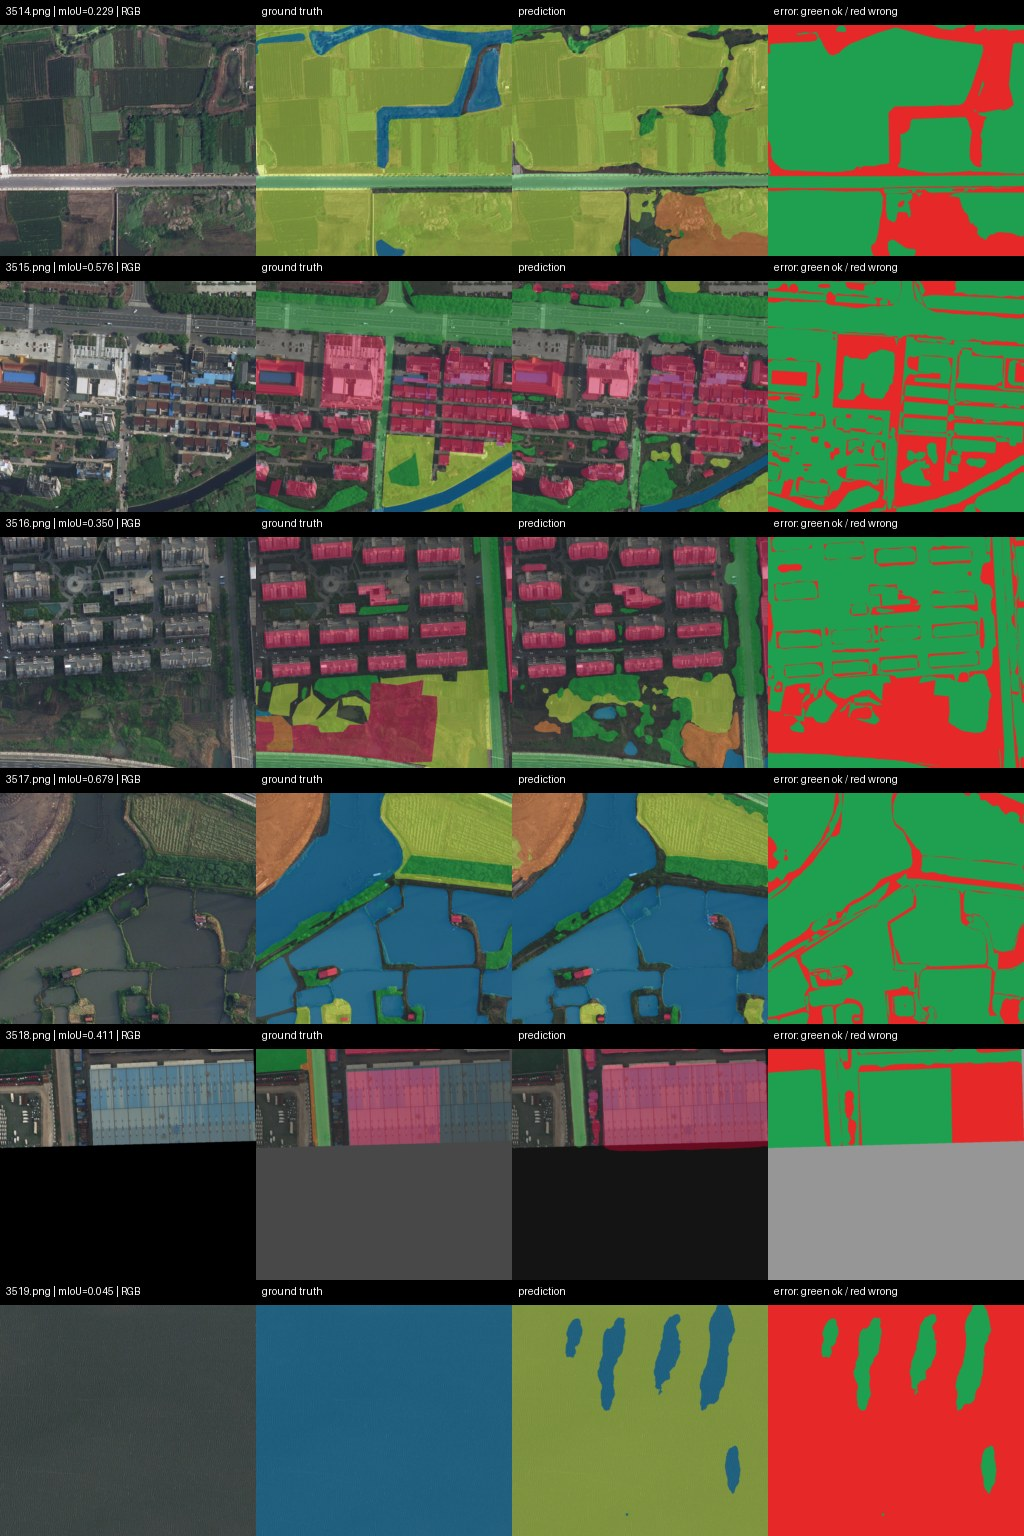

Extended LoveDA sheet omitted by default. Set `DISPLAY_EXTENDED_QUALITATIVE_FIGURES = True` to render it inline.

In [4]:
if artifact_available('Semantic-Guided CG-AF CNN LoveDA first examples'):
    display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA first examples'], 'Semantic-Guided CG-AF CNN LoveDA first examples')
    if DISPLAY_EXTENDED_QUALITATIVE_FIGURES and artifact_available('Semantic-Guided CG-AF CNN LoveDA worst examples'):
        display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA worst examples'], 'Semantic-Guided CG-AF CNN LoveDA worst examples')
    elif DISPLAY_EXTENDED_QUALITATIVE_FIGURES:
        display(Markdown('Extended LoveDA sheet requested, but the worst-example artifact is missing.'))
    else:
        display(Markdown("Extended LoveDA sheet omitted by default. Set `DISPLAY_EXTENDED_QUALITATIVE_FIGURES = True` to render it inline."))
else:
    require_artifacts(['Semantic-Guided CG-AF CNN LoveDA first examples'], 'LoveDA qualitative examples')


## 11. SAM3 class-aware pseudo-mask dataset

The original project dataset has image-level labels only. SAM3 was used offline to generate class-aware pseudo-masks, creating dense supervision for semantic distillation.

**SAM3 pseudo-mask manifest summary**

,metric,value
0,manifest_rows,2800
1,mask_schema,scene_v1
2,train_masks,2240
3,internal_tune_masks,560
4,usable_for_training,2800
5,successful_masks,2800


**SAM3 pseudo-mask class summary**

,scene_class,rows,success,foreground_coverage_mean,foreground_coverage_min,foreground_coverage_max,mask_area_px_mean
0,bridge,700,700,0.2382,0.0382,0.9991,15611.7014
1,freeway,700,700,0.5052,0.2074,0.9960,33110.5571
2,overpass,700,700,0.2299,0.0150,0.8876,15066.7143
3,railway,700,700,0.2474,0.0265,0.9972,16210.7843


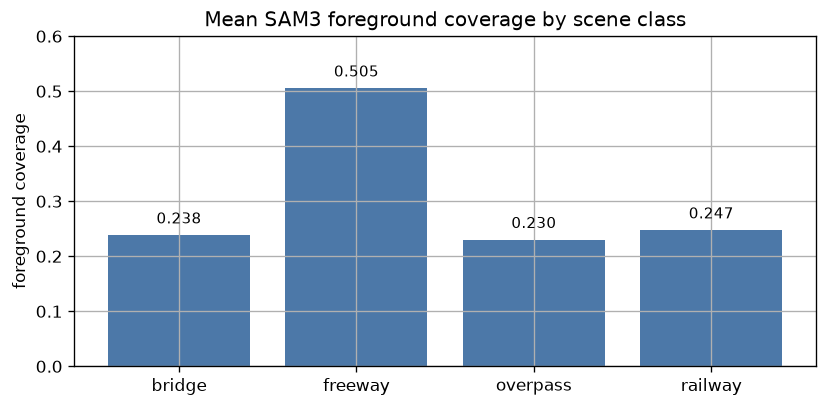

In [5]:
if require_artifacts(['SAM3 mask stats'], 'SAM3 pseudo-mask dataset'):
    mask_stats = load_json(ARTIFACTS['SAM3 mask stats'])
    mask_summary = pd.DataFrame([
        {'metric': 'manifest_rows', 'value': mask_stats['manifest_rows']},
        {'metric': 'mask_schema', 'value': mask_stats['mask_schema']},
        {'metric': 'train_masks', 'value': mask_stats['split_counts']['train']},
        {'metric': 'internal_tune_masks', 'value': mask_stats['split_counts']['internal_tune']},
        {'metric': 'usable_for_training', 'value': mask_stats['usable_for_training_counts']['true']},
        {'metric': 'successful_masks', 'value': mask_stats['status_counts']['success']},
    ])
    class_stats = (
        pd.DataFrame.from_dict(mask_stats['class_stats'], orient='index')
        .reset_index()
        .rename(columns={'index': 'scene_class'})
    )
    class_stats_view = class_stats[[
        'scene_class', 'rows', 'success', 'foreground_coverage_mean', 'foreground_coverage_min', 'foreground_coverage_max', 'mask_area_px_mean'
    ]]

    display_table(mask_summary, 'SAM3 pseudo-mask manifest summary')
    display_table(class_stats_view, 'SAM3 pseudo-mask class summary')

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(class_stats_view['scene_class'], class_stats_view['foreground_coverage_mean'], color='#4C78A8')
    ax.set_title('Mean SAM3 foreground coverage by scene class')
    ax.set_ylabel('foreground coverage')
    ax.set_ylim(0, 0.6)
    for index, value in enumerate(class_stats_view['foreground_coverage_mean']):
        ax.text(index, value + 0.015, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    mask_stats = {}


## 12. Semantic distillation and segmentation-guided classification

The Semantic-Guided CG-AF CNN model is transferred from LoveDA segmentation to the project dataset using SAM3 pseudo-masks. The scene classifier is guided by the model's predicted semantic regions.

A useful pattern in the transfer logs is that scene classification saturates quickly: macro-F1 reaches or approaches `1.0` early. Training is therefore not continued mainly to make scene classification work; it is continued to improve the semantic segmentation branch and pseudo-mask agreement, especially mIoU/Dice. This supports the transfer-learning argument: the reusable CNN encoder already carries strong scene features, while the extra epochs refine dense semantic evidence.


**Semantic-Guided CG-AF CNN SAM3 semantic transfer checkpoints**

,selection,epoch,train_accuracy,tune_accuracy,tune_macro_f1,tune_seg_pixel_accuracy,tune_seg_mean_iou,tune_seg_mean_dice,tune_loss,train_loss
0,best_segmentation_mIoU,10,1.000,1.0,1.0,0.9356,0.8102,0.891,0.6048,0.3812
1,first_best_macro_F1,3,0.996,1.0,1.0,0.9116,0.7532,0.853,0.6542,0.4844


**Transfer convergence: early scene F1 versus continued segmentation mIoU refinement**

,run,epochs_observed,first_epoch_macro_f1_ge_0_995,first_epoch_macro_f1_ge_0_999,best_macro_f1,best_macro_f1_epoch,best_seg_miou,best_seg_miou_epoch,final_seg_miou,miou_gain_after_first_f1_0_995
0,available_transfer_run,11,2,3,1.0,3,0.8102,10,0.8012,0.0835
1,staged FFT,11,2,3,1.0,3,0.8102,10,0.8012,0.0835
2,PEFT,11,2,3,1.0,3,0.7836,10,0.7816,0.0575


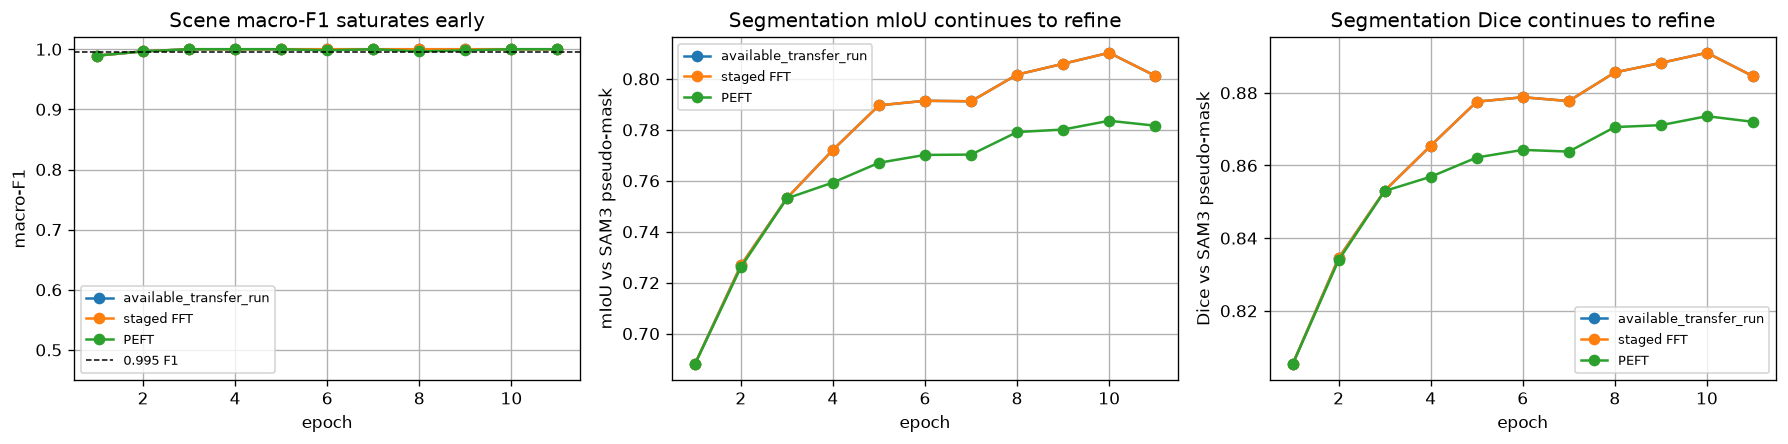

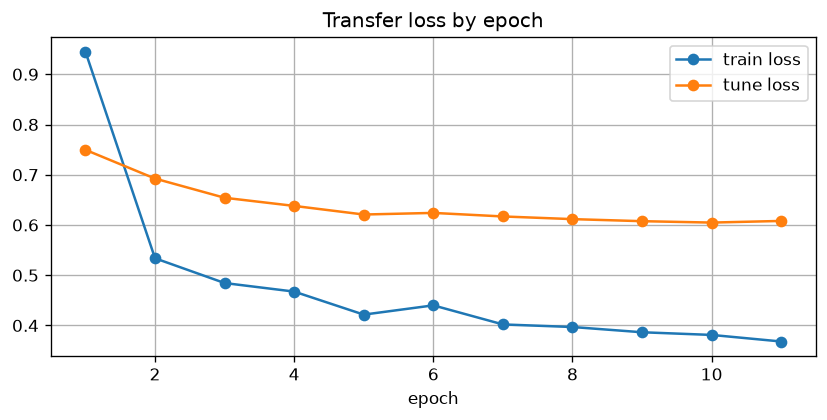

In [6]:
if require_artifacts(['SAM3 transfer history'], 'semantic transfer convergence'):
    transfer_history = load_csv(ARTIFACTS['SAM3 transfer history'])
    best_miou_row = transfer_history.loc[transfer_history['tune_seg_mean_iou'].idxmax()].copy()
    best_f1_row = transfer_history.loc[transfer_history['tune_macro_f1'].idxmax()].copy()

    best_transfer = pd.DataFrame([
        {'selection': 'best_segmentation_mIoU', **best_miou_row.to_dict()},
        {'selection': 'first_best_macro_F1', **best_f1_row.to_dict()},
    ])
    display_table(best_transfer[[
        'selection', 'epoch', 'train_accuracy', 'tune_accuracy', 'tune_macro_f1',
        'tune_seg_pixel_accuracy', 'tune_seg_mean_iou', 'tune_seg_mean_dice', 'tune_loss', 'train_loss'
    ]], 'Semantic-Guided CG-AF CNN SAM3 semantic transfer checkpoints')

    # Optional final-run PEFT/FFT histories. These are generated by training scripts and may be
    # mirrored under reports/tables/**/epoch_metrics_summary.csv or model/**/history.csv.
    def discover_transfer_histories() -> dict[str, pd.DataFrame]:
        histories: dict[str, pd.DataFrame] = {'available_transfer_run': transfer_history.copy()}
        candidate_paths = []
        candidate_paths.extend(sorted(TABLES_DIR.glob('**/epoch_metrics_summary.csv')))
        candidate_paths.extend(sorted((PROJECT_ROOT / 'model').glob('semantic_guided_cgaf_*_semantic_guided_bf16_qat_best_recipe_20260615/history.csv')))
        candidate_paths.extend(sorted((PROJECT_ROOT / 'model').glob('semantic_guided_cgaf_*_semantic_guided_bf16_qat_best_recipe_20260615/epoch_metrics_summary.csv')))
        for candidate in candidate_paths:
            try:
                history = load_csv(candidate)
            except Exception:
                continue
            required = {'epoch', 'tune_macro_f1', 'tune_seg_mean_iou'}
            if not required.issubset(history.columns):
                continue
            text = str(candidate).lower()
            if 'peft' in text:
                name = 'PEFT'
            elif 'fft' in text:
                name = 'staged FFT'
            elif name := candidate.parent.name:
                name = name.replace('semantic_guided_cgaf_', '').replace('_semantic_guided_bf16_qat_best_recipe_20260615', '')
            histories[name] = history.copy()
        return histories

    transfer_histories = discover_transfer_histories()
    convergence_rows = []
    for run_name, history in transfer_histories.items():
        f1 = history['tune_macro_f1'].astype(float)
        miou = history['tune_seg_mean_iou'].astype(float)
        epoch = history['epoch'].astype(int)
        reaches_999 = history.loc[f1 >= 0.999]
        reaches_995 = history.loc[f1 >= 0.995]
        convergence_rows.append({
            'run': run_name,
            'epochs_observed': int(len(history)),
            'first_epoch_macro_f1_ge_0_995': None if reaches_995.empty else int(reaches_995['epoch'].iloc[0]),
            'first_epoch_macro_f1_ge_0_999': None if reaches_999.empty else int(reaches_999['epoch'].iloc[0]),
            'best_macro_f1': float(f1.max()),
            'best_macro_f1_epoch': int(history.loc[f1.idxmax(), 'epoch']),
            'best_seg_miou': float(miou.max()),
            'best_seg_miou_epoch': int(history.loc[miou.idxmax(), 'epoch']),
            'final_seg_miou': float(miou.iloc[-1]),
            'miou_gain_after_first_f1_0_995': None if reaches_995.empty else float(miou.max() - float(history.loc[history['epoch'].eq(reaches_995['epoch'].iloc[0]), 'tune_seg_mean_iou'].iloc[0])),
        })
    convergence = pd.DataFrame(convergence_rows)
    display_table(convergence, 'Transfer convergence: early scene F1 versus continued segmentation mIoU refinement')

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    for run_name, history in transfer_histories.items():
        label = run_name
        axes[0].plot(history['epoch'], history['tune_macro_f1'], marker='o', label=label)
        axes[1].plot(history['epoch'], history['tune_seg_mean_iou'], marker='o', label=label)
        axes[2].plot(history['epoch'], history['tune_seg_mean_dice'], marker='o', label=label)
    axes[0].axhline(0.995, color='black', linestyle='--', linewidth=0.9, label='0.995 F1')
    axes[0].set_title('Scene macro-F1 saturates early')
    axes[0].set_ylabel('macro-F1')
    axes[0].set_ylim(0.45, 1.02)
    axes[1].set_title('Segmentation mIoU continues to refine')
    axes[1].set_ylabel('mIoU vs SAM3 pseudo-mask')
    axes[2].set_title('Segmentation Dice continues to refine')
    axes[2].set_ylabel('Dice vs SAM3 pseudo-mask')
    for ax in axes:
        ax.set_xlabel('epoch')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.plot(transfer_history['epoch'], transfer_history['train_loss'], marker='o', label='train loss')
    ax.plot(transfer_history['epoch'], transfer_history['tune_loss'], marker='o', label='tune loss')
    ax.set_title('Transfer loss by epoch')
    ax.set_xlabel('epoch')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    transfer_history = pd.DataFrame()
    display(Markdown('Transfer convergence plot skipped because the epoch history artifact is missing.'))


### Convergence interpretation

The convergence plot is meant to separate two effects that are easy to conflate:

- **Scene classification transfer is easy for this architecture when the final training logs are available.** PEFT and staged FFT histories reach near-ceiling macro-F1 early in those best-recipe logs, showing that the reusable CNN encoder already carries strong scene-discriminative features.
- **The reason to keep training is semantic quality.** Later epochs are justified by improved segmentation pseudo-mask agreement (`tune_seg_mean_iou` / Dice), not by needing many epochs to make the classifier work.

If only the currently mirrored transfer history is available locally, the cell still renders that run and automatically expands to PEFT/FFT once their `history.csv` or `epoch_metrics_summary.csv` files are copied back into `model/` or `reports/tables/`.


### SAM3 pseudo-mask examples

The grids below show class-aware SAM3 pseudo-mask examples used for offline data distillation. When the older transfer-prediction grid is available, it is shown; otherwise the class-aware SAM3 grids are rendered directly.


**SAM3 class-aware pseudo-mask examples — bridge**

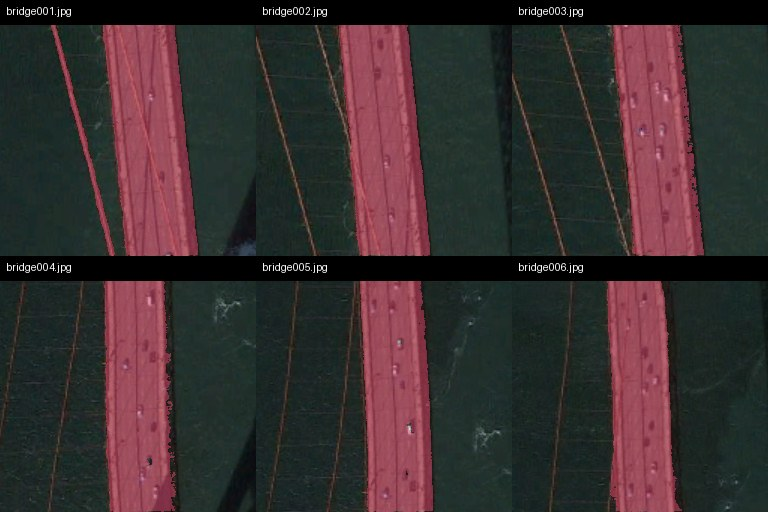

**SAM3 class-aware pseudo-mask examples — freeway**

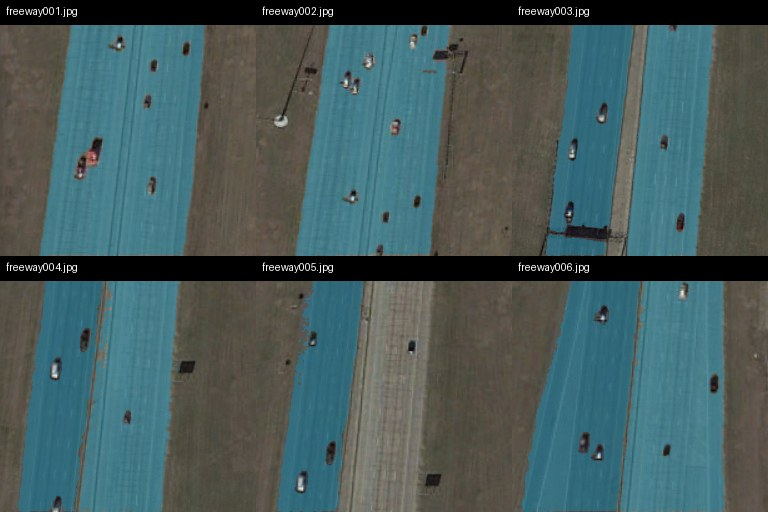

**SAM3 class-aware pseudo-mask examples — overpass**

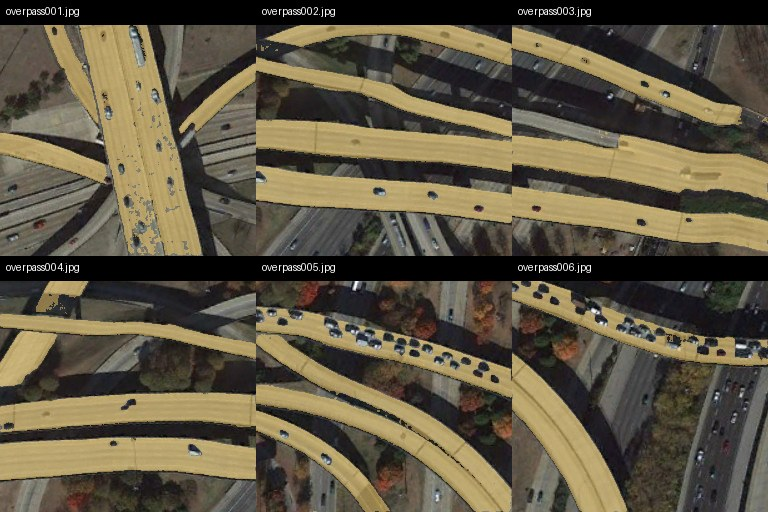

**SAM3 class-aware pseudo-mask examples — railway**

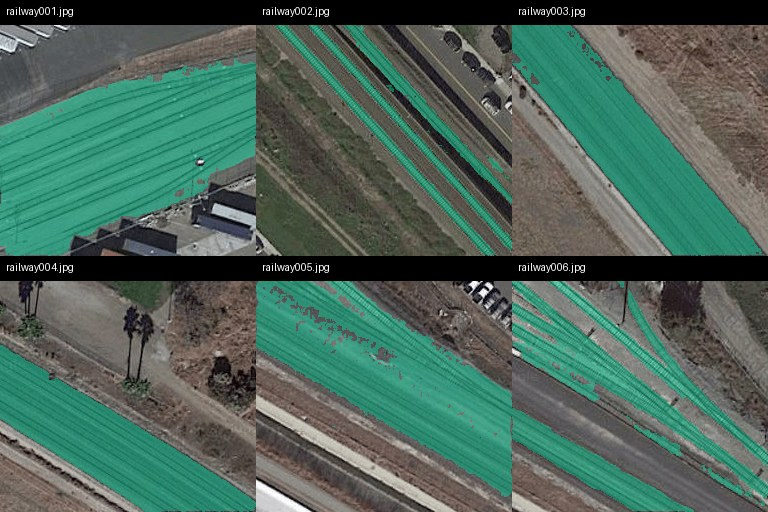

In [7]:
if artifact_available('Semantic-Guided CG-AF CNN SAM3 example grid'):
    display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN SAM3 example grid'], 'Semantic-Guided CG-AF CNN SAM3 semantic transfer examples')
else:
    sam3_example_dir = FIGURE_ARTIFACTS.get('SAM3 class-aware example dir', FIGURES_DIR / 'semantic_sam3_class_aware_examples' / 'full')
    rendered_any = False
    for scene in CLASS_NAMES:
        candidate = sam3_example_dir / f'{scene}_semantic_overlay_grid.png'
        if candidate.exists():
            display_image_artifact(candidate, f'SAM3 class-aware pseudo-mask examples — {scene}', width=1100)
            rendered_any = True
    if not rendered_any:
        require_artifacts(['Semantic-Guided CG-AF CNN SAM3 example grid'], 'SAM3 pseudo-mask examples')


## 13. Why QAT, PTQ, AWQ-style emulation, and ONNX QDQ?

Because edge deployment is the priority, the notebook evaluates quantisation stability directly, but it separates **research quantisation experiments** from **deployment-realistic export**.

**QAT** (**Q**uantisation **A**ware **T**raining) exposes the model to fake W8A8 quantisation during training, so the model learns under quantised-like numerics instead of being quantised only after training.

**PTQ** (**P**ost **T**raining **Q**uantisation) is the realistic baseline for post-training quantisation behaviour: calibrate activation ranges, quantise eligible Conv2d/Linear weights, and evaluate without retraining.

**AWQ-style W8A8 PyTorch emulation** is the bleeding-edge experimentation track. It uses activation statistics to emulate activation-aware protection/scaling of important channels and asks whether the architecture remains robust under more advanced quantisation ideas. It is intentionally labelled as an emulation/proxy, not as a native deployment artifact.

**ONNX INT8 QDQ** is the primary deployment path. It converts the trained model into a standard ONNX graph and applies ONNX Runtime static INT8 QDQ calibration, yielding a more realistic subset of operations for mobile/edge NPU compilers than custom PyTorch emulation.


## 14. Quantisation caveat

The PTQ/AWQ rows below are PyTorch-side numerical studies. They show whether the model's classification and segmentation behavior survives quantisation pressure before committing to a deployment export path.

The native deployment lane is ONNX: FP32 ONNX export followed by full-calibrated ONNX Runtime INT8 QDQ. That path is still not a guarantee of a specific NPU speedup, but it is materially closer to deployment because it uses standard ONNX quantised graph patterns.

So the roles are:

- **PTQ:** realistic baseline for calibrated post-training quantisation behavior;
- **ONNX INT8 QDQ:** selected deployment-realistic export path for edge/NPU validation;
- **AWQ-style emulation:** research-only activation-aware robustness experiment used to ask whether denser semantic masks can survive quantisation pressure better than blanket QDQ.


## 15. Why staged FFT is selected over PEFT

Both Parameter Efficient Fine-Tuning (PEFT), in this case transfer learning with frozen encoder weights, and staged Full Fine-Tuning (FFT) were evaluated for the same Semantic-Guided CG-AF CNN architecture.

PEFT is attractive because it is cheaper to adapt and reaches high scene-level F1 quickly. However, PEFT shows notably lower segmentation performance and mIoU than staged FFT, and the AWQ-style evaluation exposes a few closer confusion/failure cases. Since the deployed model emits both `scene_logits` and `segmentation_logits`, classification accuracy alone is not sufficient.

Staged FFT is therefore selected because it preserves the reusable CNN encoder while allowing the dense decoder, segmentation head, and scene head to co-adapt. In practice it gives stronger pseudo-mask mIoU/Dice and better quantisation stability. The rest of the deployment analysis therefore focuses on the FFT checkpoint exported through ONNX FP32 and full-calibrated ONNX INT8 QDQ.


**Semantic-Guided CG-AF CNN quantisation robustness summary**

,candidate,mode,weight_bits,activation_bits,awq_enabled,accuracy,macro_precision,macro_recall,macro_f1,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice
0,fft,fp32,NaN,NaN,False,1.0000,1.0000,1.0000,1.0000,0.9355,0.8112,0.8916
1,fft,awq_w8a8,8.0,8.0,True,1.0000,1.0000,1.0000,1.0000,0.9355,0.8106,0.8912
2,peft,fp32,NaN,NaN,False,0.9982,0.9982,0.9982,0.9982,0.9091,0.7520,0.8527
3,peft,awq_w8a8,8.0,8.0,True,0.9982,0.9982,0.9982,0.9982,0.9119,0.7543,0.8538


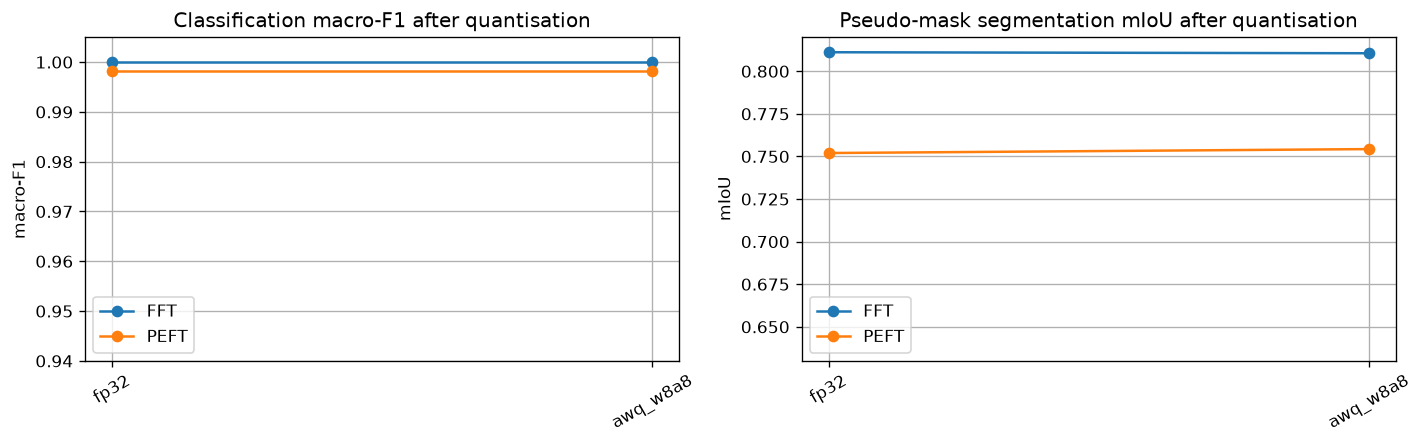

In [8]:
if require_artifacts(['Actual quant summary'], 'PEFT vs staged FFT quantisation summary'):
    quant_summary = load_csv(ARTIFACTS['Actual quant summary'])
    required_quant_columns = {
        'checkpoint_name', 'mode', 'classification_accuracy', 'macro_f1',
        'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
    }
    assert required_quant_columns.issubset(quant_summary.columns), 'Quant summary schema changed.'
    assert ((quant_summary['checkpoint_name'] == 'fft') & (quant_summary['mode'].astype(str).eq('fp32'))).any(), 'Missing FFT raw row.'
    assert ((quant_summary['checkpoint_name'] == 'fft') & (quant_summary['mode'].astype(str).eq('awq_w8a8'))).any(), 'Missing FFT AWQ W8A8 row.'
    assert ((quant_summary['checkpoint_name'] == 'peft') & (quant_summary['mode'].astype(str).eq('fp32'))).any(), 'Missing PEFT raw row.'
    assert ((quant_summary['checkpoint_name'] == 'peft') & (quant_summary['mode'].astype(str).eq('awq_w8a8'))).any(), 'Missing PEFT AWQ W8A8 row.'
    mode_order = ['fp32', 'awq_w8a8', 'ptq_w8a8', 'ptq_w4a8', 'awq_w4a8']
    quant_summary['mode'] = pd.Categorical(quant_summary['mode'], categories=mode_order, ordered=True)
    quant_summary = quant_summary.sort_values(['checkpoint_name', 'mode']).reset_index(drop=True)

    quant_view = quant_summary[[
        'checkpoint_name', 'mode', 'weight_bits', 'activation_bits', 'awq_enabled',
        'classification_accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
        'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
    ]].rename(columns={
        'checkpoint_name': 'candidate',
        'classification_accuracy': 'accuracy',
    })
    display_table(quant_view, 'Semantic-Guided CG-AF CNN quantisation robustness summary')

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
    for candidate, group in quant_summary.groupby('checkpoint_name', observed=False):
        axes[0].plot(group['mode'].astype(str), group['macro_f1'], marker='o', label=candidate.upper())
        axes[1].plot(group['mode'].astype(str), group['seg_mean_iou'], marker='o', label=candidate.upper())
    axes[0].set_title('Classification macro-F1 after quantisation')
    axes[0].set_ylabel('macro-F1')
    axes[0].set_ylim(0.94, 1.005)
    axes[1].set_title('Pseudo-mask segmentation mIoU after quantisation')
    axes[1].set_ylabel('mIoU')
    axes[1].set_ylim(0.63, 0.82)
    for ax in axes:
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    quant_summary = pd.DataFrame()


## 16. Native ONNX INT8 QDQ: deployment-realistic quantisation path

After selecting staged FFT over PEFT, the deployment analysis focuses only on the FFT checkpoint. Deployment still needs a standard export format. The chosen deployment path is therefore native ONNX INT8 QDQ:

1. BF16-trained staged FFT `Semantic-Guided CG-AF CNN` checkpoint;
2. dynamic-batch FP32 ONNX export with outputs `segmentation_logits` and `scene_logits`;
3. ONNX Runtime static INT8 QDQ/PTQ with full train-split calibration (`MinMax`, 2240 calibration images);
4. unseen `data/val 12` ImageFolder evaluation for ONNX FP32 and ONNX INT8 QDQ.

The ONNX INT8 result below is **standard calibrated QDQ/PTQ**, not ONNX AWQ. This makes the deployment claim cleaner: ONNX INT8 QDQ is the realistic NPU-oriented export path, while AWQ-style emulation is kept as a separate research-only robustness probe.


In [9]:
ONNX_EVAL_DIR = pipeline_output_path('onnx_eval_dir')
ONNX_VAL12_TABLE_DIR = pipeline_output_path('unseen_output_dir')
ONNX_VAL12_REVIEW_DIR = pipeline_output_path('unseen_review_dir')
ONNX_VAL12_MASK_DIR = pipeline_output_path('unseen_mask_dir')

onnx_artifacts = pd.DataFrame([
    {'artifact': 'ONNX full-calibrated comparison table', 'path': ONNX_EVAL_DIR / 'comparison_table.csv'},
    {'artifact': 'ONNX runtime summary', 'path': ONNX_EVAL_DIR / 'runtime_summary.csv'},
    {'artifact': 'ONNX drift summary', 'path': ONNX_EVAL_DIR / 'drift_summary.csv'},
    {'artifact': 'Unseen val12 summary', 'path': ONNX_VAL12_TABLE_DIR / 'summary.csv'},
    {'artifact': 'Unseen val12 per-image predictions', 'path': ONNX_VAL12_TABLE_DIR / 'per_image_predictions.csv'},
    {'artifact': 'ONNX delivery size summary', 'path': ONNX_VAL12_TABLE_DIR / 'onnx_delivery_size_summary.csv'},
    {'artifact': 'Near-confusion pair summary', 'path': ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_pair_summary.csv'},
    {'artifact': 'Near-confusion low-margin examples', 'path': ONNX_VAL12_REVIEW_DIR / 'onnx_lowest_margin_top20.csv'},
    {'artifact': 'Corrected val12 review figures', 'path': ONNX_VAL12_REVIEW_DIR},
    {'artifact': 'Full-calibrated val12 predicted masks', 'path': ONNX_VAL12_MASK_DIR},
])
onnx_artifacts['exists'] = onnx_artifacts['path'].map(lambda p: Path(p).exists())
onnx_artifacts['relative_path'] = onnx_artifacts['path'].map(lambda p: str(Path(p).relative_to(PROJECT_ROOT)) if Path(p).is_relative_to(PROJECT_ROOT) else str(p))
display_table(onnx_artifacts[['artifact', 'exists', 'relative_path']], 'Native ONNX artifact availability')
ONNX_AVAILABLE = bool(onnx_artifacts['exists'].all())
if not ONNX_AVAILABLE:
    missing_onnx = ', '.join(onnx_artifacts.loc[~onnx_artifacts['exists'], 'relative_path'])
    display(Markdown(f'**ONNX artifact section partially skipped:** missing `{missing_onnx}`. Copy/generated ONNX artifacts to render all deployment tables and figures.'))

onnx_eval = load_csv(ONNX_EVAL_DIR / 'comparison_table.csv') if (ONNX_EVAL_DIR / 'comparison_table.csv').exists() else pd.DataFrame()
onnx_runtime = load_csv(ONNX_EVAL_DIR / 'runtime_summary.csv') if (ONNX_EVAL_DIR / 'runtime_summary.csv').exists() else pd.DataFrame()
onnx_drift = load_csv(ONNX_EVAL_DIR / 'drift_summary.csv') if (ONNX_EVAL_DIR / 'drift_summary.csv').exists() else pd.DataFrame()
val12_summary = load_csv(ONNX_VAL12_TABLE_DIR / 'summary.csv') if (ONNX_VAL12_TABLE_DIR / 'summary.csv').exists() else pd.DataFrame()
val12_predictions = load_csv(ONNX_VAL12_TABLE_DIR / 'per_image_predictions.csv') if (ONNX_VAL12_TABLE_DIR / 'per_image_predictions.csv').exists() else pd.DataFrame()
onnx_delivery = load_csv(ONNX_VAL12_TABLE_DIR / 'onnx_delivery_size_summary.csv') if (ONNX_VAL12_TABLE_DIR / 'onnx_delivery_size_summary.csv').exists() else pd.DataFrame()
near_margin = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_margin_summary.csv') if (ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_margin_summary.csv').exists() else pd.DataFrame()
near_pairs = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_pair_summary.csv') if (ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_pair_summary.csv').exists() else pd.DataFrame()
near_lowest = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_lowest_margin_top20.csv') if (ONNX_VAL12_REVIEW_DIR / 'onnx_lowest_margin_top20.csv').exists() else pd.DataFrame()


**Native ONNX artifact availability**

,artifact,exists,relative_path
0,ONNX full-calibrated comparison table,True,reports/tables/semantic_guided_cgaf_onnx_eval_...
1,ONNX runtime summary,True,reports/tables/semantic_guided_cgaf_onnx_eval_...
2,ONNX drift summary,True,reports/tables/semantic_guided_cgaf_onnx_eval_...
3,Unseen val12 summary,True,reports/tables/semantic_guided_cgaf_unseen_val...
4,Unseen val12 per-image predictions,True,reports/tables/semantic_guided_cgaf_unseen_val...
5,ONNX delivery size summary,True,reports/tables/semantic_guided_cgaf_unseen_val...
6,Near-confusion pair summary,True,reports/figures/semantic_guided_cgaf_unseen_va...
7,Near-confusion low-margin examples,True,reports/figures/semantic_guided_cgaf_unseen_va...
8,Corrected val12 review figures,True,reports/figures/semantic_guided_cgaf_unseen_va...
9,Full-calibrated val12 predicted masks,True,reports/figures/semantic_guided_cgaf_unseen_va...


### ONNX confusion matrices on unseen data `val 12`

Since we have selected the deployment model, this next step verifies performance based on confusion matrices computed from the unseen `data/val 12` ImageFolder evaluation. After full train-split MinMax calibration, ONNX INT8 QDQ reaches the same 400/400 classification accuracy as Torch BF16 and ONNX FP32.


**Unseen val12 classification and segmentation-logit agreement**

,variant,runtime,precision_mode,observed_images,accuracy,macro_f1,scene_pred_agreement_vs_reference,seg_pixel_agreement_vs_reference
0,torch_bf16,torch,bf16,400,1.0,1.0,NaN,NaN
1,onnx_fp32,onnxruntime,fp32,400,1.0,1.0,1.0,0.9994
2,onnx_int8_qdq,onnxruntime,int8_qdq,400,1.0,1.0,1.0,0.9732


**Torch BF16 val12 confusion**

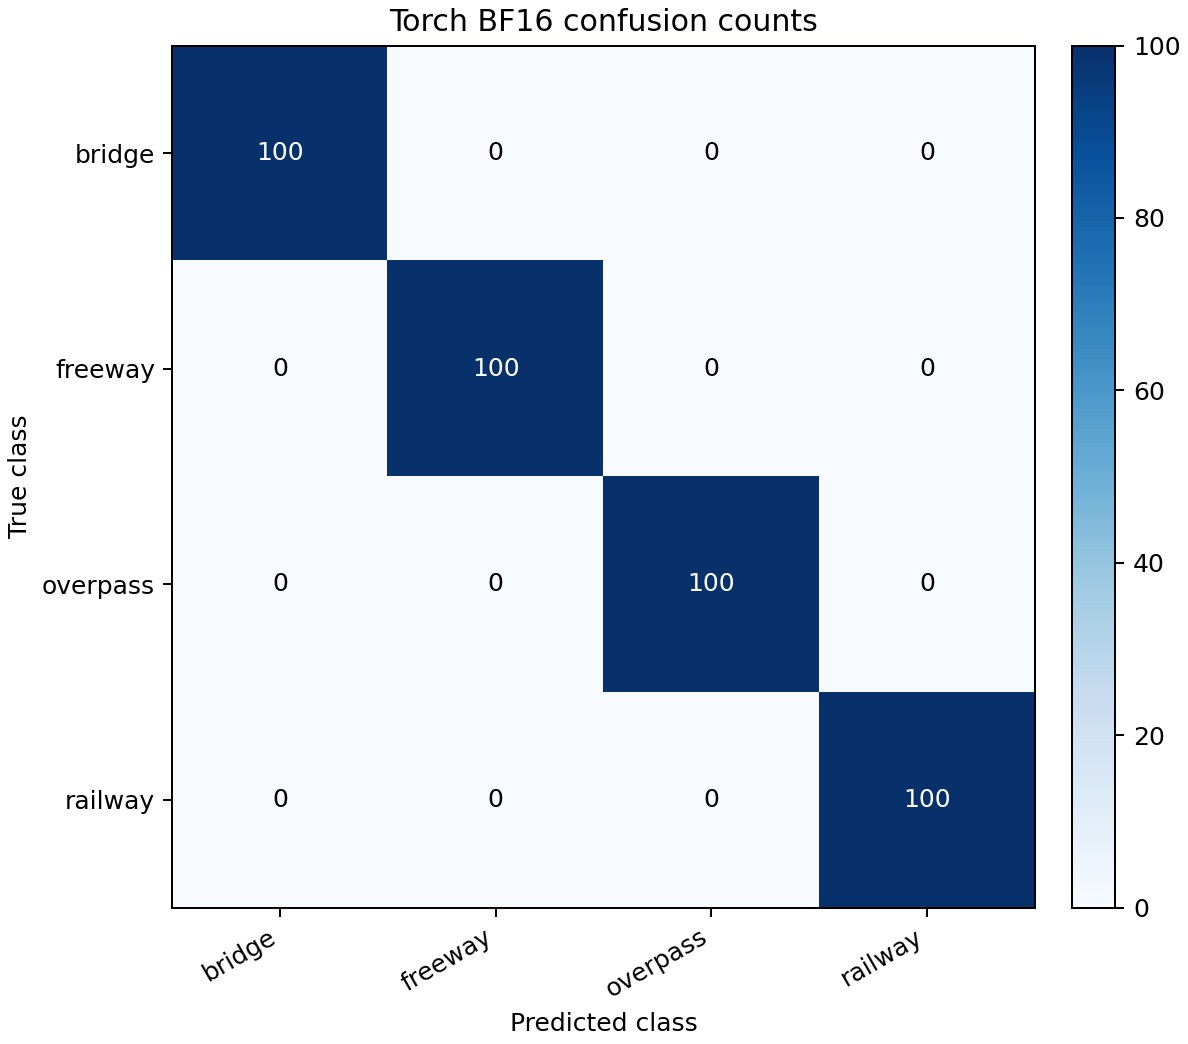

**ONNX FP32 val12 confusion**

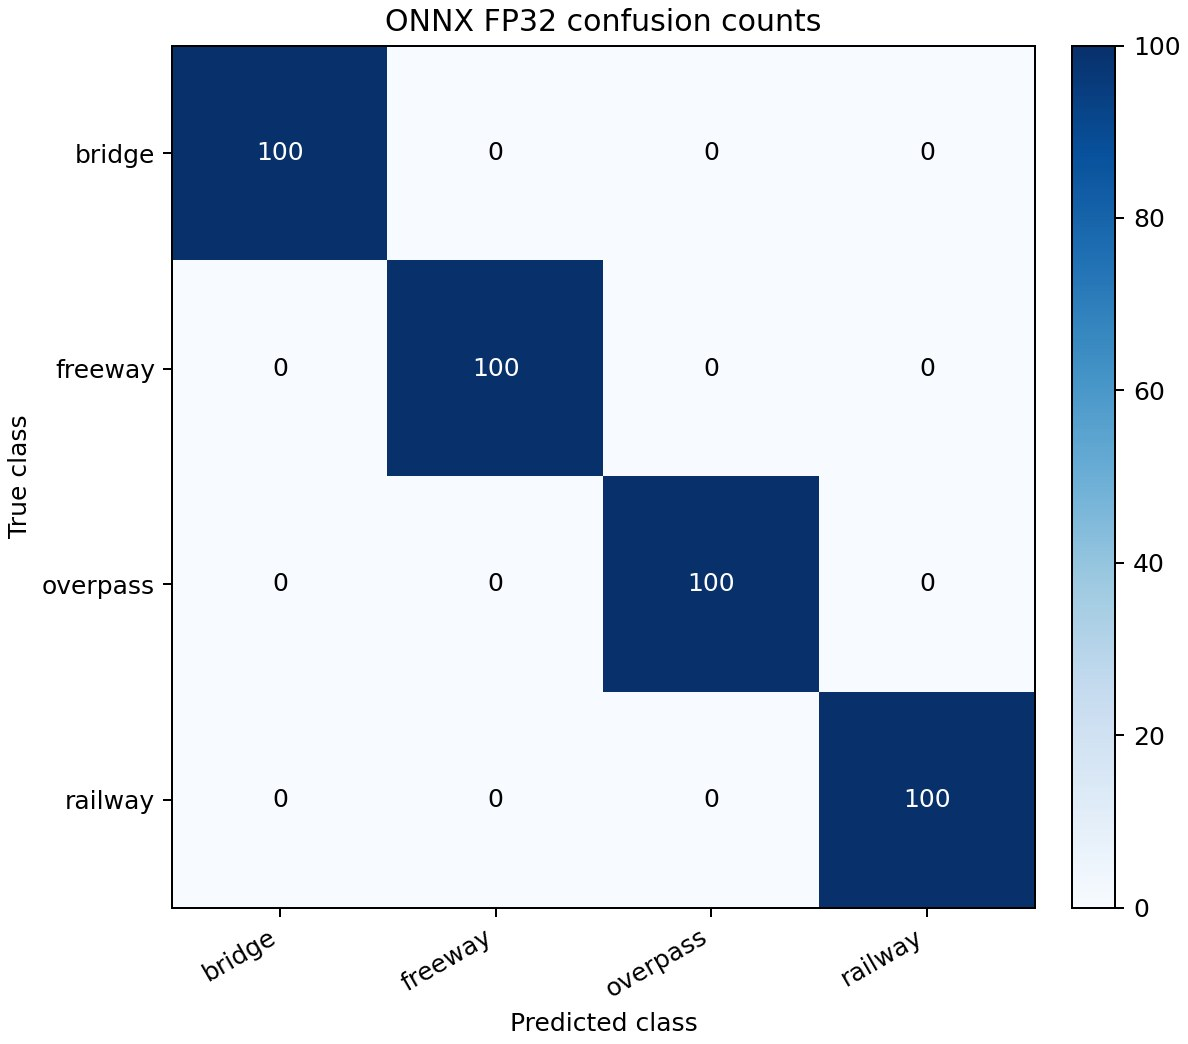

**ONNX INT8 QDQ full-calibrated val12 confusion**

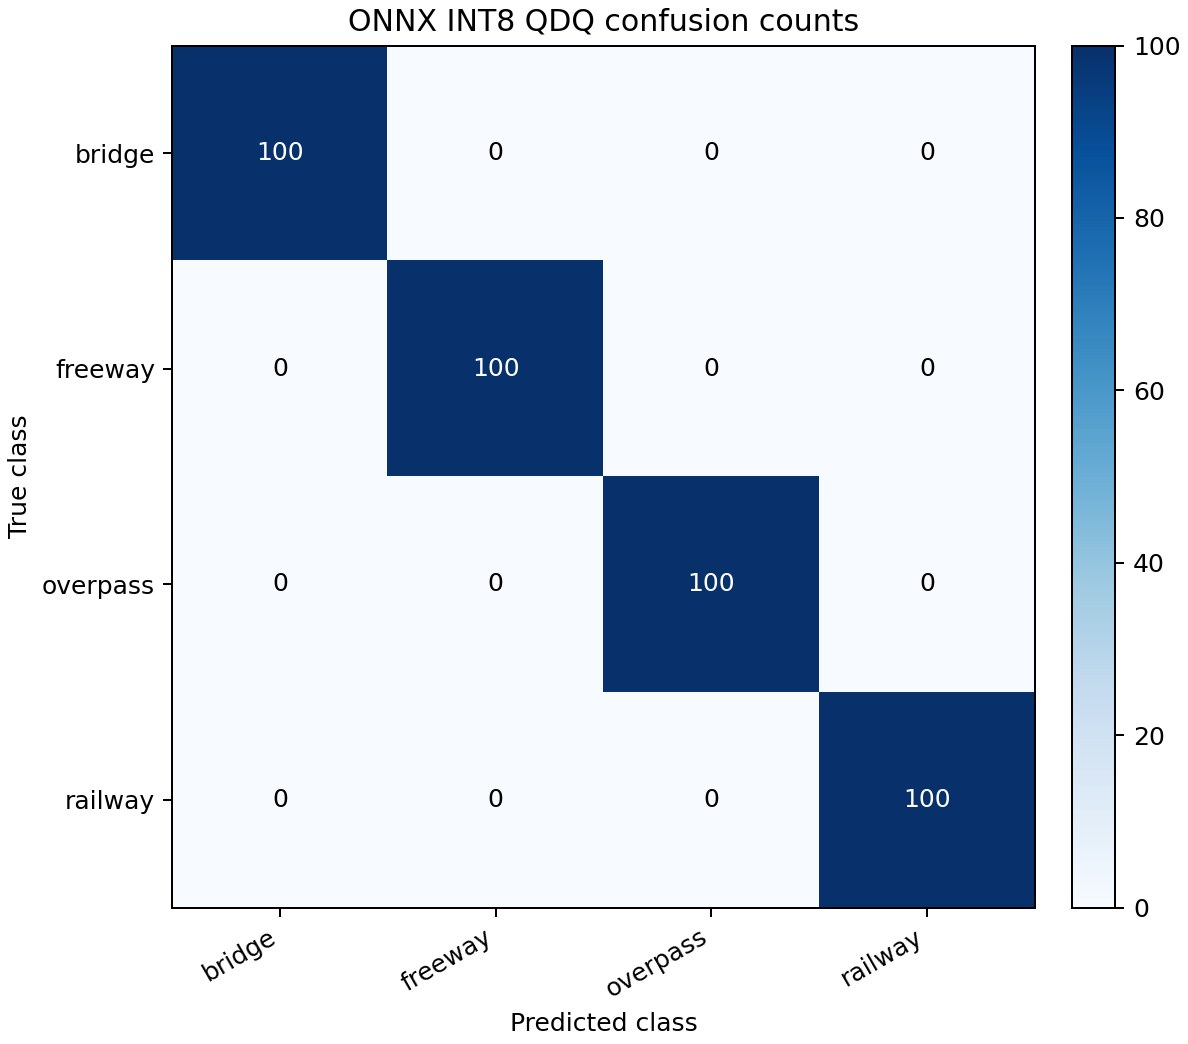

In [10]:
if not val12_summary.empty:
    val12_view = val12_summary[[
        'variant', 'runtime', 'precision_mode', 'observed_images', 'accuracy', 'macro_f1',
        'scene_pred_agreement_vs_reference', 'seg_pixel_agreement_vs_reference',
    ]].copy()
    display_table(val12_view, 'Unseen val12 classification and segmentation-logit agreement')

    confusion_variants = [
        ('torch_bf16', 'Torch BF16 val12 confusion'),
        ('onnx_fp32', 'ONNX FP32 val12 confusion'),
        ('onnx_int8_qdq', 'ONNX INT8 QDQ full-calibrated val12 confusion'),
    ]
    if 'torch_awq_w8a8_emulated' in set(val12_summary.get('variant', [])):
        confusion_variants.append(('torch_awq_w8a8_emulated', 'AWQ-style W8A8 val12 confusion'))

    for variant, title in confusion_variants:
        display_image_artifact(
            ONNX_VAL12_REVIEW_DIR / 'plots' / f'{variant}_confusion_counts.png',
            title,
            width=700,
        )
else:
    display(Markdown('ONNX val12 summary is unavailable; confusion matrices skipped.'))


### Potential almost-confused classes

Mean confidence is less useful when nearly all examples are easy. The more diagnostic signal is the **top-1 vs top-2 margin** and the runner-up class. Smaller margins indicate classes that the model nearly confused.

After full INT8 calibration there are no classification errors, but the remaining low-margin case is still informative: `railway701.jpg` is correctly predicted as `railway`, with `freeway` as runner-up.


**ONNX near-confusion margin summary**

,variant,images,min_margin,p01_margin,p05_margin,p10_margin,median_margin,max_runner_up_probability,count_margin_lt_0_50,count_margin_lt_0_35,count_margin_lt_0_25
0,onnx_fp32,400,0.1304,0.9267,0.9464,0.9489,0.9553,0.3812,1,1,1
1,onnx_int8_qdq,400,0.3330,0.8667,0.9262,0.9310,0.9463,0.2454,1,1,0


**ONNX INT8 QDQ almost-confused class pairs**

,true_class_name,runner_up_class_name,count,min_margin,max_runner_up_probability,count_margin_lt_0_50,count_margin_lt_0_35
12,railway,freeway,59,0.3330,0.2454,1,1
13,railway,bridge,18,0.6993,0.1226,0,0
14,railway,overpass,23,0.7048,0.1042,0,0
15,bridge,overpass,38,0.7165,0.1287,0,0
16,overpass,freeway,36,0.8682,0.0394,0,0
17,overpass,railway,57,0.9084,0.0285,0,0
18,freeway,overpass,67,0.9159,0.0287,0,0
19,bridge,railway,52,0.9199,0.0214,0,0
20,freeway,railway,26,0.9247,0.0201,0,0
21,freeway,bridge,7,0.9412,0.0152,0,0


**Lowest-margin ONNX INT8 QDQ examples**

,image_name,true_class_name,predicted_class_name,runner_up_class_name,top1_probability,runner_up_probability,top1_top2_margin
20,railway701.jpg,railway,railway,freeway,0.5784,0.2454,0.3330
21,railway710.jpg,railway,railway,bridge,0.8219,0.1226,0.6993
22,railway714.jpg,railway,railway,overpass,0.8091,0.1042,0.7048
23,bridge751.jpg,bridge,bridge,overpass,0.8452,0.1287,0.7165
24,overpass798.jpg,overpass,overpass,freeway,0.9077,0.0394,0.8682
25,railway760.jpg,railway,railway,bridge,0.9199,0.0399,0.8800
26,railway795.jpg,railway,railway,freeway,0.9272,0.0320,0.8952
27,overpass703.jpg,overpass,overpass,freeway,0.9391,0.0360,0.9032
28,overpass797.jpg,overpass,overpass,railway,0.9369,0.0285,0.9084
29,railway793.jpg,railway,railway,freeway,0.9386,0.0257,0.9129


**ONNX INT8 QDQ lowest margin by true/runner-up class**

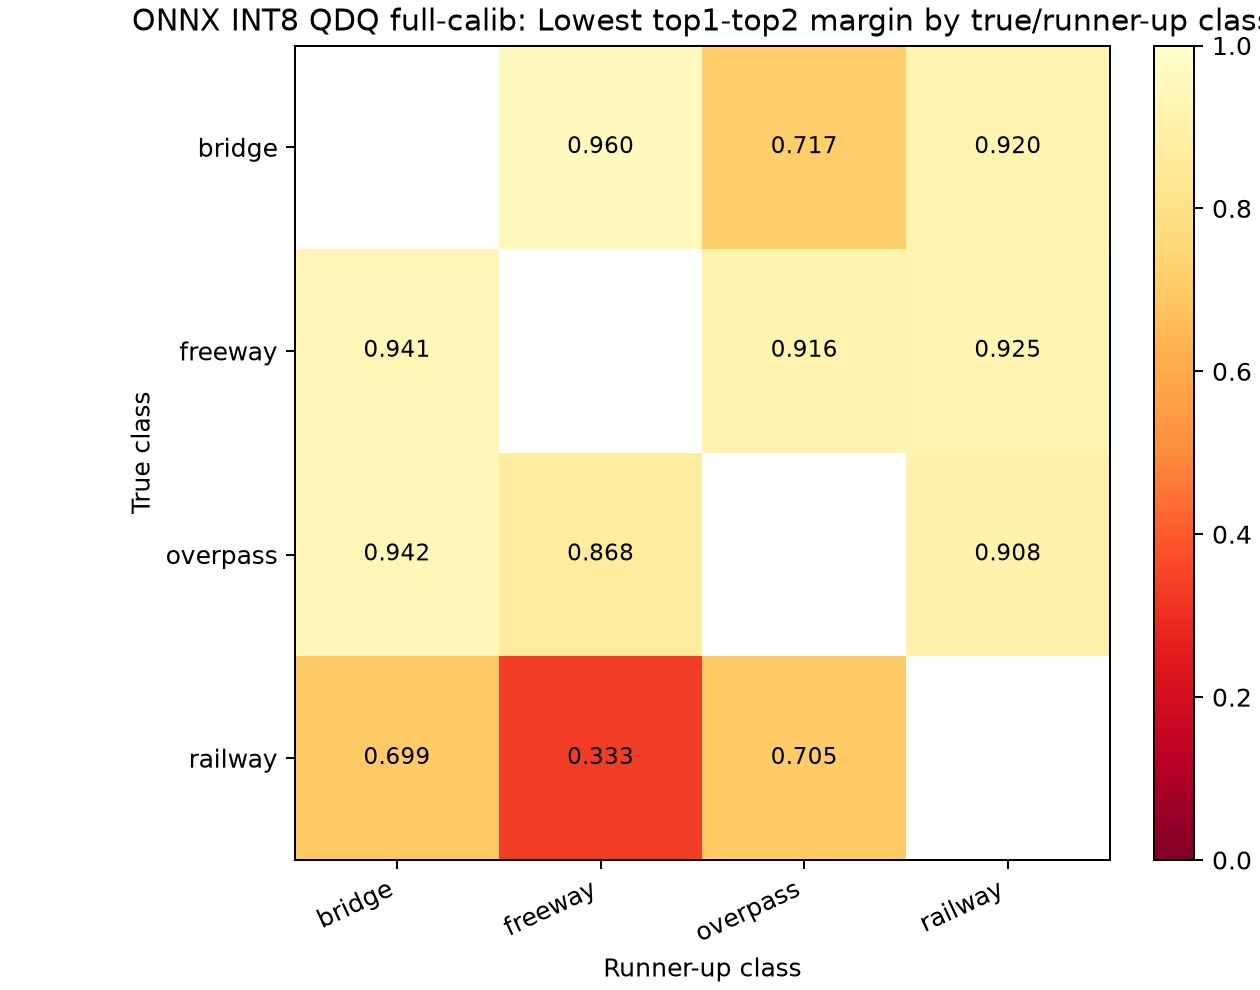

**ONNX INT8 QDQ highest runner-up probability by true/runner-up class**

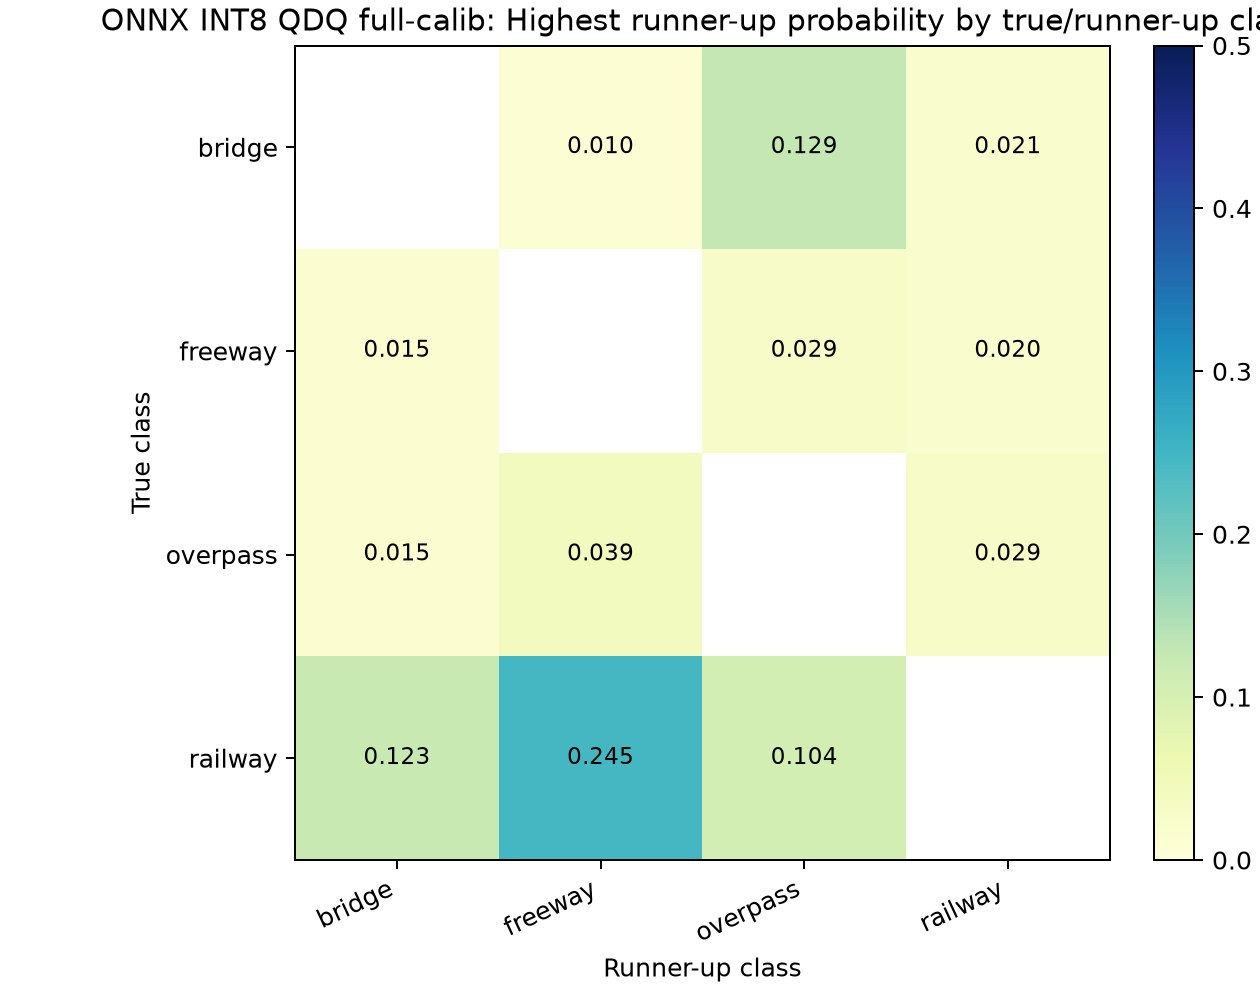

In [11]:
if not near_margin.empty and not near_pairs.empty and not near_lowest.empty:
    display_table(
        near_margin[[
            'variant', 'images', 'min_margin', 'p01_margin', 'p05_margin', 'p10_margin',
            'median_margin', 'max_runner_up_probability', 'count_margin_lt_0_50',
            'count_margin_lt_0_35', 'count_margin_lt_0_25',
        ]],
        'ONNX near-confusion margin summary',
    )

    int8_pairs = near_pairs.loc[near_pairs['variant'].eq('onnx_int8_qdq'), [
        'true_class_name', 'runner_up_class_name', 'count', 'min_margin',
        'max_runner_up_probability', 'count_margin_lt_0_50', 'count_margin_lt_0_35',
    ]].head(12)
    display_table(int8_pairs, 'ONNX INT8 QDQ almost-confused class pairs')

    int8_lowest = near_lowest.loc[near_lowest['variant'].eq('onnx_int8_qdq'), [
        'image_name', 'true_class_name', 'predicted_class_name', 'runner_up_class_name',
        'top1_probability', 'runner_up_probability', 'top1_top2_margin',
    ]].head(10)
    display_table(int8_lowest, 'Lowest-margin ONNX INT8 QDQ examples')

    for path, title in [
        (ONNX_VAL12_REVIEW_DIR / 'plots' / 'onnx_int8_qdq_near_confusion_min_margin.png', 'ONNX INT8 QDQ lowest margin by true/runner-up class'),
        (ONNX_VAL12_REVIEW_DIR / 'plots' / 'onnx_int8_qdq_near_confusion_max_runner_up_probability.png', 'ONNX INT8 QDQ highest runner-up probability by true/runner-up class'),
    ]:
        display_image_artifact(path, title, width=800)
else:
    display(Markdown('ONNX near-confusion artifacts are unavailable; near-confusion tables skipped.'))


### Qualitative ONNX masks and segmentation caveat

These are predicted masks only: `val 12` does not contain segmentation ground truth, so no val12 mIoU is reported. This section intentionally compares only **ONNX FP32** and **full-calibrated ONNX INT8 QDQ**; Torch BF16 is omitted because it is effectively identical to ONNX FP32 for this qualitative purpose.

The corrected INT8 QDQ model preserves scene classification on `val 12`, and its pseudo-mask mIoU remains within an acceptable range on the internal SAM3-labelled evaluation. However, qualitative evidence shows a clear drop in dense semantic understanding under INT8 QDQ. 

To better illustrate model performance, we evaluated the model performance against real world images taken from Google Earth and images from the provided validation set.


**Unseen val12 ONNX-only sample panels: RGB + ONNX FP32 / ONNX INT8 QDQ masks**

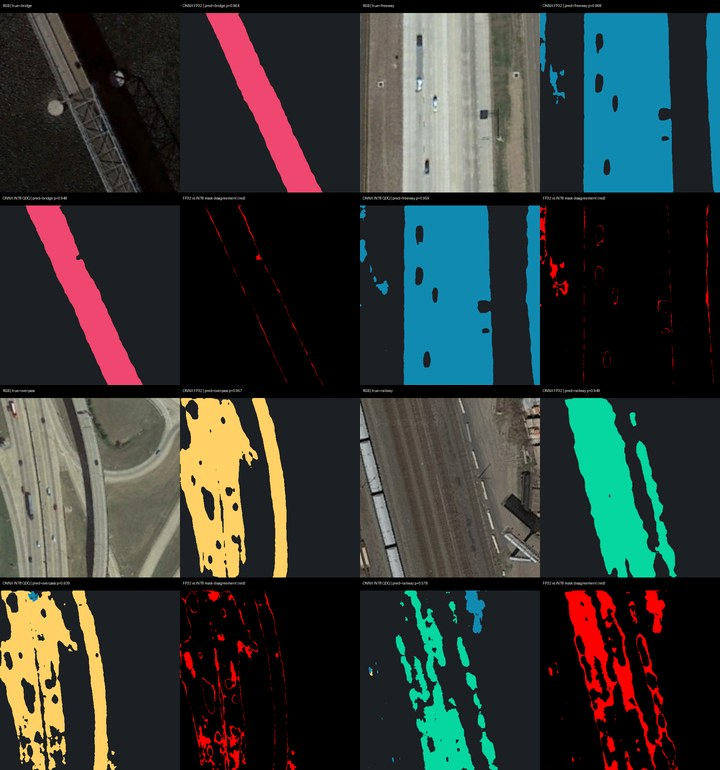

**Lowest-margin val12 case after full calibration: railway701, ONNX FP32 vs INT8 QDQ**

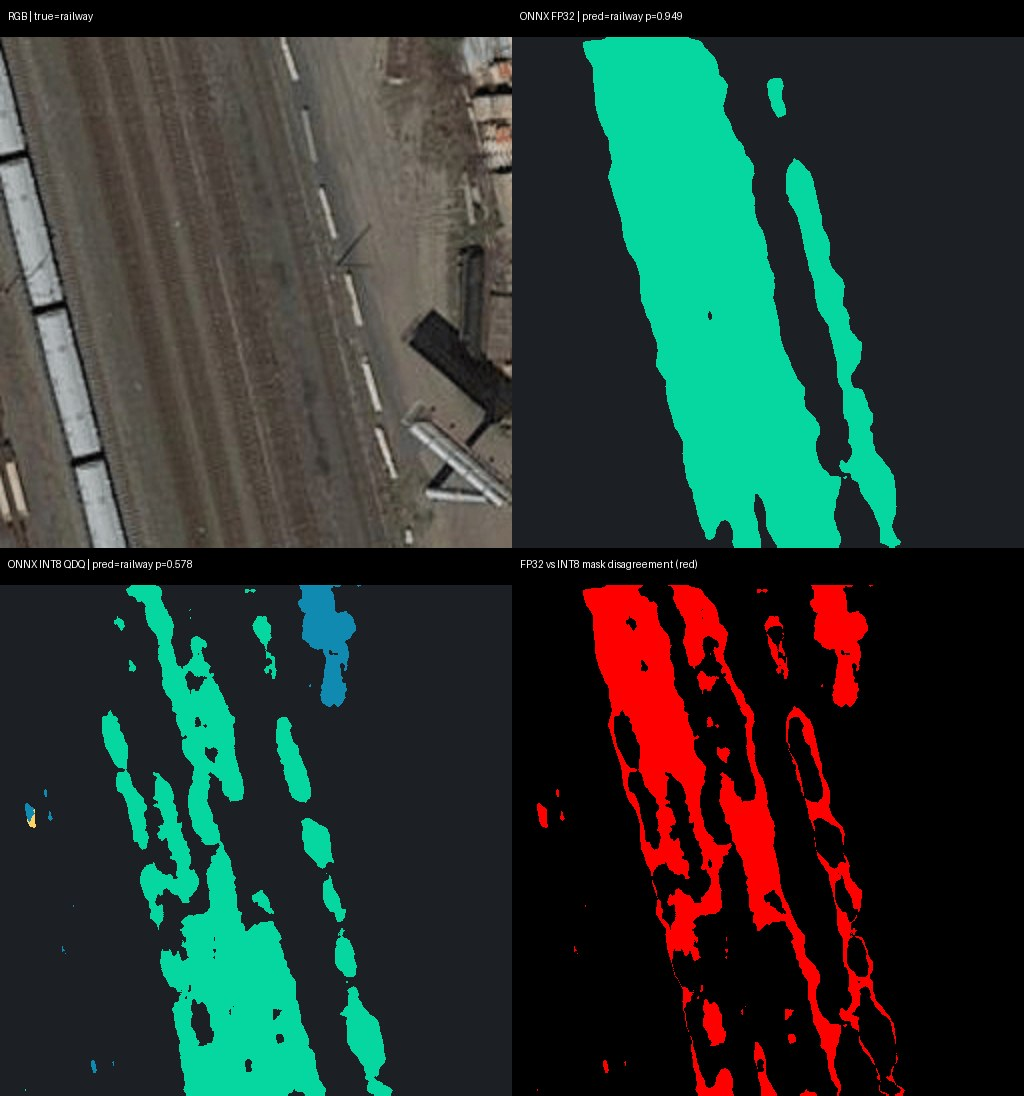

**OOD Johor interchange: ONNX FP32 vs INT8 QDQ segmentation degradation**

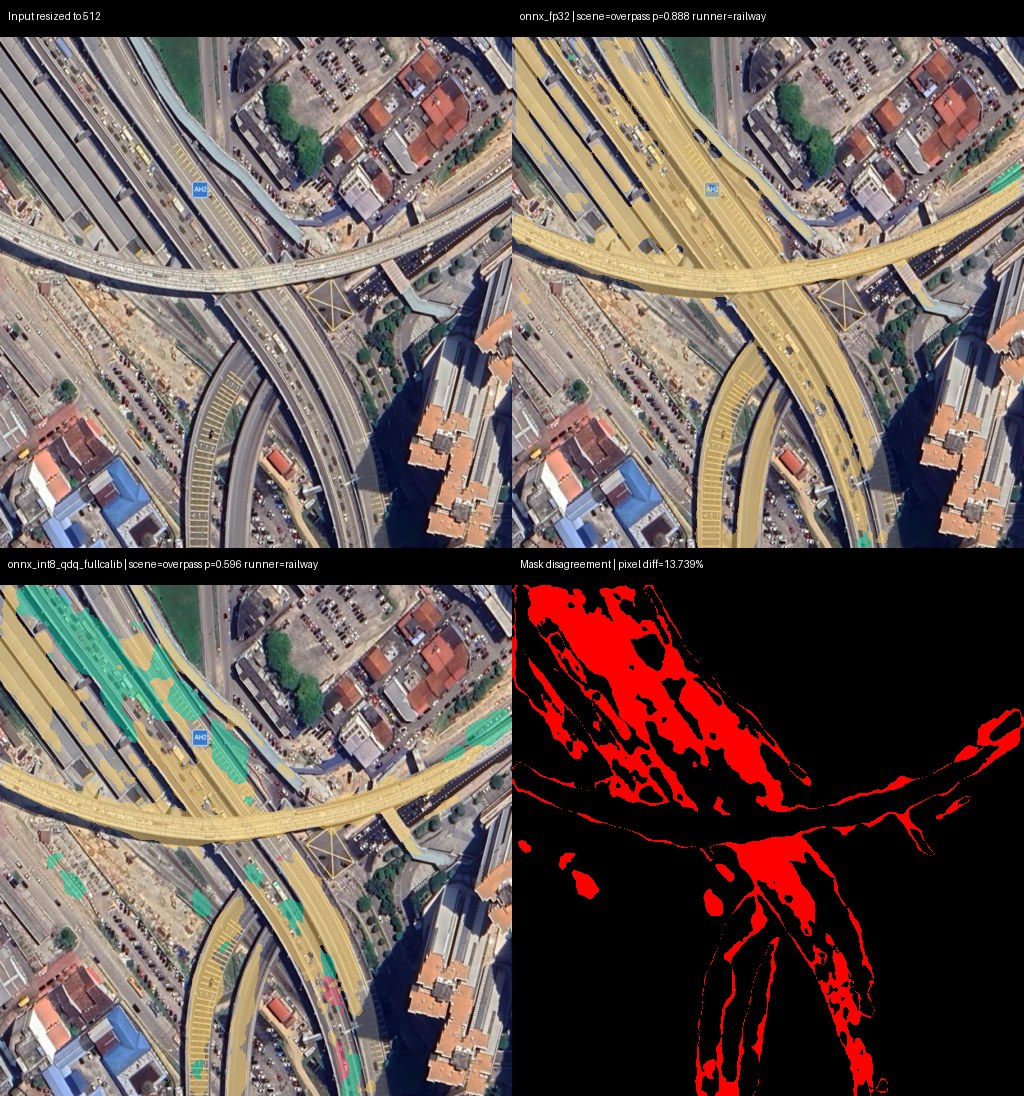

In [12]:
onnx_only_sheet = ONNX_VAL12_REVIEW_DIR / 'onnx_only_sample_panels_contact_sheet.png'
johor_panel = pipeline_output_path('onnx_case_study_dir') / 'johor_onnx_fp32_int8_comparison_panel.png'
railway_panel = ONNX_VAL12_REVIEW_DIR / 'onnx_only_panels' / 'railway701_onnx_fp32_int8_panel.png'

if onnx_only_sheet.exists():
    display_image_artifact(
        onnx_only_sheet,
        'Unseen val12 ONNX-only sample panels: RGB + ONNX FP32 / ONNX INT8 QDQ masks',
        width=950,
    )
    if railway_panel.exists():
        display_image_artifact(
            railway_panel,
            'Lowest-margin val12 case after full calibration: railway701, ONNX FP32 vs INT8 QDQ',
            width=950,
        )
else:
    display(Markdown('ONNX-only qualitative mask panels are unavailable; copy/generated review figures to render them.'))

if johor_panel.exists():
    display_image_artifact(
        johor_panel,
        'OOD Johor interchange: ONNX FP32 vs INT8 QDQ segmentation degradation',
        width=1000,
    )
else:
    display(Markdown('Johor ONNX comparison panel is unavailable; generate the `onnx-case-study` pipeline stage to render the OOD caveat.'))


### Qualitative evidence: INT8 QDQ preserves scene classification but weakens dense segmentation
A particularly challenging example is the Johor/CIQ interchange shown above, taken from Google Earth as a real-world stress case. Both ONNX variants correctly classify the scene as `overpass`, but their dense semantic outputs differ: INT8 QDQ shifts meaningful foreground structure into `railway` and background relative to FP32. In this tile, the quantised model appears to assign railway labels to regions that are not visually consistent with railway infrastructure, indicating that dense segmentation is more sensitive to quantisation than the scene classification head.

A similar failure mode appears in the lowest-margin `val 12` case. The INT8 QDQ model still classifies the image correctly as `railway`, but parts of the predicted mask are classified as `freeway`. This image also contains visible JPEG compression artifacts, suggesting another edge case where INT8 quantisation can degrade segmentation quality while preserving classification accuracy.

### ONNX export/evaluation performance and deployable payload

The ONNX evaluator validates the FP32 ONNX and calibrated INT8 QDQ artifacts against the BF16-trained checkpoint. Runtime measurements below use the available execution provider in the experiment environment; ONNX Runtime CUDA was not available on `vaporeon`, so ONNX rows were measured with `CPUExecutionProvider`. The more important deployment result for this section is correctness stability, graph portability, and payload size.


In [13]:
if not onnx_eval.empty and not onnx_delivery.empty:
    onnx_eval_view = onnx_eval.loc[
        onnx_eval['variant'].isin(['torch_bf16', 'onnx_fp32', 'onnx_int8_qdq']),
        [
            'variant', 'runtime', 'device_or_provider', 'precision_mode', 'native_deployment_artifact',
            'calibration_image_count', 'calibration_method', 'classification_accuracy',
            'seg_mean_iou_vs_sam3', 'scene_pred_agreement_vs_torch_fp32',
            'seg_pixel_agreement_vs_torch_fp32', 'artifact_size_bytes',
        ],
    ].copy()
    onnx_eval_view['artifact_mib'] = onnx_eval_view['artifact_size_bytes'] / (1024 * 1024)
    display_table(onnx_eval_view, 'Full-calibrated ONNX evaluator summary')

    delivery_view = onnx_delivery[[
        'artifact', 'raw_mib', 'gzip_mib', 'gzip_ratio', 'raw_path', 'gzip_path',
    ]].copy()
    display_table(delivery_view, 'ONNX edge-delivery payload size')

    fp32 = onnx_delivery.loc[onnx_delivery['artifact'].eq('onnx_fp32')].iloc[0]
    int8 = onnx_delivery.loc[onnx_delivery['artifact'].eq('onnx_int8_qdq_fullcalib_minmax')].iloc[0]
    edge_delivery_md = f'''
    **Edge-delivery calculation**

    - FP32 ONNX: {fp32['raw_mib']:.2f} MiB raw, {fp32['gzip_mib']:.2f} MiB gzip/DEFLATE.
    - Full-calibrated INT8 QDQ ONNX: {int8['raw_mib']:.2f} MiB raw, {int8['gzip_mib']:.2f} MiB gzip/DEFLATE.
    - Raw INT8 is {fp32['raw_mib'] / int8['raw_mib']:.2f}x smaller than raw FP32 ONNX.
    - Compressed INT8 is {fp32['gzip_mib'] / int8['gzip_mib']:.2f}x smaller than compressed FP32 ONNX.

    At 3–5 Mbps GEO uplink rates, the 18.70 MiB compressed INT8 payload corresponds to roughly 30–60 seconds of airtime before protocol/weather/congestion overhead.
    '''
    display(Markdown(edge_delivery_md))
else:
    display(Markdown('ONNX evaluator or delivery-size tables are unavailable; deployment payload table skipped.'))


**Full-calibrated ONNX evaluator summary**

,variant,runtime,device_or_provider,precision_mode,native_deployment_artifact,calibration_image_count,calibration_method,classification_accuracy,seg_mean_iou_vs_sam3,scene_pred_agreement_vs_torch_fp32,seg_pixel_agreement_vs_torch_fp32,artifact_size_bytes,artifact_mib
1,torch_bf16,torch,cuda,cuda_autocast_bf16,False,NaN,NaN,1.0,0.9461,1.0,0.9995,341830437,325.9949
3,onnx_fp32,onnxruntime,CPUExecutionProvider,fp32,True,NaN,NaN,1.0,0.9461,1.0,1.0000,113980546,108.7003
4,onnx_int8_qdq,onnxruntime,CPUExecutionProvider,int8_qdq,True,2240.0,minmax,1.0,0.9376,1.0,0.9881,29321225,27.9629


**ONNX edge-delivery payload size**

,artifact,raw_mib,gzip_mib,gzip_ratio,raw_path,gzip_path
0,onnx_fp32,108.7003,100.9514,0.9287,model/semantic_guided_cgaf_onnx_exports_smoke_...,model/semantic_guided_cgaf_onnx_exports_smoke_...
1,onnx_int8_qdq_fullcalib_minmax,27.9629,18.6963,0.6686,model/semantic_guided_cgaf_onnx_int8_fullcalib...,model/semantic_guided_cgaf_onnx_int8_fullcalib...



    **Edge-delivery calculation**

    - FP32 ONNX: 108.70 MiB raw, 100.95 MiB gzip/DEFLATE.
    - Full-calibrated INT8 QDQ ONNX: 27.96 MiB raw, 18.70 MiB gzip/DEFLATE.
    - Raw INT8 is 3.89x smaller than raw FP32 ONNX.
    - Compressed INT8 is 5.40x smaller than compressed FP32 ONNX.

    At 3–5 Mbps GEO uplink rates, the 18.70 MiB compressed INT8 payload corresponds to roughly 30–60 seconds of airtime before protocol/weather/congestion overhead.
    

### Deployment interpretation

The native ONNX lane supports the architectural feasibility argument: the model keeps its dominant workload in CNN-style operators, exports to standard ONNX, and can be calibrated into an INT8 QDQ graph. That is a more realistic NPU path than relying on arbitrary transformer attention patterns or custom AWQ operators.

Operationally, the corrected INT8 result is attractive when the ONNX artifacts are available: the calibrated INT8 ONNX artifact is 27.96 MiB raw and 18.70 MiB compressed, while preserving 400/400 scene accuracy on the unseen `val 12` split. The segmentation caveat matters, though: the dense decoder is more quantisation-sensitive than the scene head, as the Johor qualitative example shows.

That caveat motivates the next research-only section: can activation-aware weight quantisation preserve segmentation quality better than blanket ONNX QDQ, even if ONNX remains the realistic deployment target?


## 17. Bonus research question: can AWQ-style quantisation preserve segmentation quality beyond ONNX QDQ?

The deployment path remains ONNX INT8 QDQ because it uses standard graph operations that are more likely to be accepted by mobile/edge NPU compilers. Custom AWQ-style PyTorch emulation may require operation patterns or packing semantics that an NPU compiler does not support, which can defeat the purpose of an edge-first model.

However, the qualitative ONNX INT8 results show that dense segmentation is more fragile than scene classification. Moreover, Pareto-frontier Large Language Model deployments are headed towards **Activation Weight Aware Quantisation** or AWQ, trading off compatibility for greater model efficacy under quantisation pressure, preserving performance whilst reducing model weight size and memory requirements.

This motivates a research-only question: **can activation-aware weight quantisation preserve the semantic segmentation branch better than blanket calibrated QDQ?**

The AWQ-style W8A8 comparison below is therefore a bonus research probe, not the deployment conclusion. It compares the FFT AWQ-style PyTorch emulation against the deployable ONNX INT8 QDQ result on the same challenging case studies.


In [14]:
if require_artifacts(['AWQ W8A8 summary', 'AWQ example metadata'], 'AWQ-style W8A8 stability check'):
    awq_export_summary = load_csv(ARTIFACTS['AWQ W8A8 summary'])
    awq_examples = load_csv(ARTIFACTS['AWQ example metadata'])
    assert set(awq_export_summary['quant_mode']).issubset({'awq_w8a8'}), 'Mask-export summary must be AWQ W8A8.'
    assert set(awq_examples['quant_mode']).issubset({'awq_w8a8'}), 'Mask-export manifest must be AWQ W8A8.'
    required_checkpoints = {'peft', 'fft'}
    assert required_checkpoints.issubset(set(awq_export_summary['checkpoint'])), 'Missing expected AWQ W8A8 checkpoint rows.'
    awq_summary = awq_export_summary.assign(
        model=lambda df: df['checkpoint'] + '_awq_w8a8',
        accuracy=lambda df: df['classification_accuracy'],
        macro_f1=lambda df: df['classification_macro_f1'],
        seg_pixel_accuracy=lambda df: df['seg_pixel_accuracy_vs_sam3'],
        seg_mean_iou=lambda df: df['seg_mean_iou_vs_sam3'],
        seg_mean_dice=lambda df: df['seg_mean_dice_vs_sam3'],
    )
    per_scene_rows = []
    for checkpoint in ['peft', 'fft']:
        pred_col = f'{checkpoint}_pred_scene_name'
        iou_col = f'{checkpoint}_iou'
        dice_col = f'{checkpoint}_dice'
        pixel_col = f'{checkpoint}_pixel_accuracy'
        temp = awq_examples.assign(classification_correct=awq_examples[pred_col].eq(awq_examples['true_scene_name']))
        grouped = temp.groupby('scene_class_name', as_index=False).agg(
            samples=('export_id', 'count'),
            classification_correct=('classification_correct', 'sum'),
            classification_accuracy=('classification_correct', 'mean'),
            seg_pixel_accuracy=(pixel_col, 'mean'),
            seg_mean_iou=(iou_col, 'mean'),
            seg_mean_dice=(dice_col, 'mean'),
        )
        grouped.insert(0, 'model', f'{checkpoint}_awq_w8a8')
        grouped = grouped.rename(columns={'scene_class_name': 'scene'})
        per_scene_rows.append(grouped)
    awq_scene = pd.concat(per_scene_rows, ignore_index=True)
    display_table(awq_summary[[
        'model', 'accuracy', 'macro_f1', 'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
    ]], 'AWQ W8A8 PEFT vs staged FFT summary')
    display_table(awq_scene[[
        'model', 'scene', 'samples', 'classification_accuracy', 'classification_correct',
        'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
    ]], 'AWQ W8A8 per-scene metrics')
else:
    awq_export_summary = pd.DataFrame()
    awq_examples = pd.DataFrame()
    awq_summary = pd.DataFrame()
    awq_scene = pd.DataFrame()


**AWQ W8A8 PEFT vs staged FFT summary**

,model,accuracy,macro_f1,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice
0,fft_awq_w8a8,1.0000,1.0000,0.9355,0.8106,0.8912
1,peft_awq_w8a8,0.9982,0.9982,0.9119,0.7543,0.8538


**AWQ W8A8 per-scene metrics**

,model,scene,samples,classification_accuracy,classification_correct,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice
0,peft_awq_w8a8,bridge,140,1.0000,140,0.9350,0.8537,0.9044
1,peft_awq_w8a8,freeway,140,1.0000,140,0.9482,0.8922,0.9373
2,peft_awq_w8a8,overpass,140,1.0000,140,0.8709,0.7014,0.7968
3,peft_awq_w8a8,railway,140,0.9929,139,0.8935,0.7233,0.8149
4,fft_awq_w8a8,bridge,140,1.0000,140,0.9540,0.8976,0.9324
5,fft_awq_w8a8,freeway,140,1.0000,140,0.9686,0.9370,0.9657
6,fft_awq_w8a8,overpass,140,1.0000,140,0.9001,0.7788,0.8580
7,fft_awq_w8a8,railway,140,1.0000,140,0.9195,0.7898,0.8693


### AWQ-style robustness confusion matrices

These supplemental confusion matrices summarize the custom AWQ-style W8A8 PyTorch robustness study. The deployment-facing confusion matrices remain the ONNX `val 12` results above. The AWQ matrices are included to show why staged FFT was selected as the robust checkpoint before export.


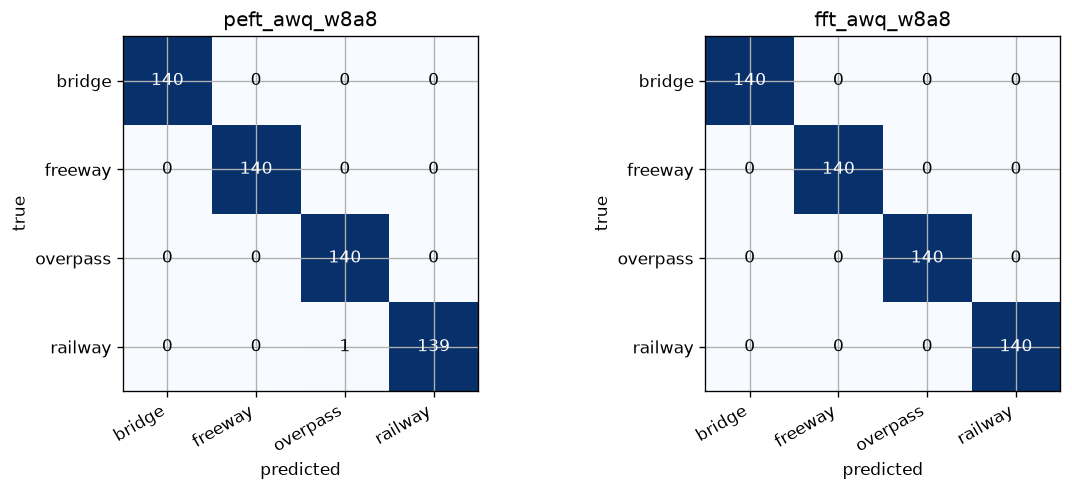

In [15]:
def plot_confusion(ax, matrix: np.ndarray, title: str) -> None:
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_xticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES)
    max_value = matrix.max() if matrix.size else 0
    threshold = max_value / 2 if max_value else 0
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            color = 'white' if matrix[row, col] > threshold else 'black'
            ax.text(col, row, str(matrix[row, col]), ha='center', va='center', color=color, fontsize=10)
    return image


def confusion_from_examples(df: pd.DataFrame, pred_col: str) -> np.ndarray:
    matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
    class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    for _, row in df.iterrows():
        true_idx = class_to_idx[row['true_scene_name']]
        pred_idx = class_to_idx[row[pred_col]]
        matrix[true_idx, pred_idx] += 1
    return matrix


if 'awq_examples' in globals() and isinstance(awq_examples, pd.DataFrame) and not awq_examples.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, checkpoint in zip(axes, ['peft', 'fft']):
        cm = confusion_from_examples(awq_examples, f'{checkpoint}_pred_scene_name')
        plot_confusion(ax, cm, f'{checkpoint}_awq_w8a8')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('AWQ-style confusion matrices skipped because AWQ example metadata is missing. See the ONNX val12 confusion matrices above when available.'))


### AWQ-style qualitative segmentation evidence

The exported review panels compare PEFT, FFT, and SAM3 pseudo-labels under the custom AWQ-style W8A8 emulation. They are research-only qualitative evidence for activation-aware quantisation robustness, not native deployment artifacts.

SAM3, PEFT, and FFT have different failure modes: SAM3 can over-cover the scene, PEFT can produce tighter object-like masks but is less stable after quantisation, and FFT often matches the pseudo-label objective more strongly.


**AWQ W8A8 review panel — bridge**

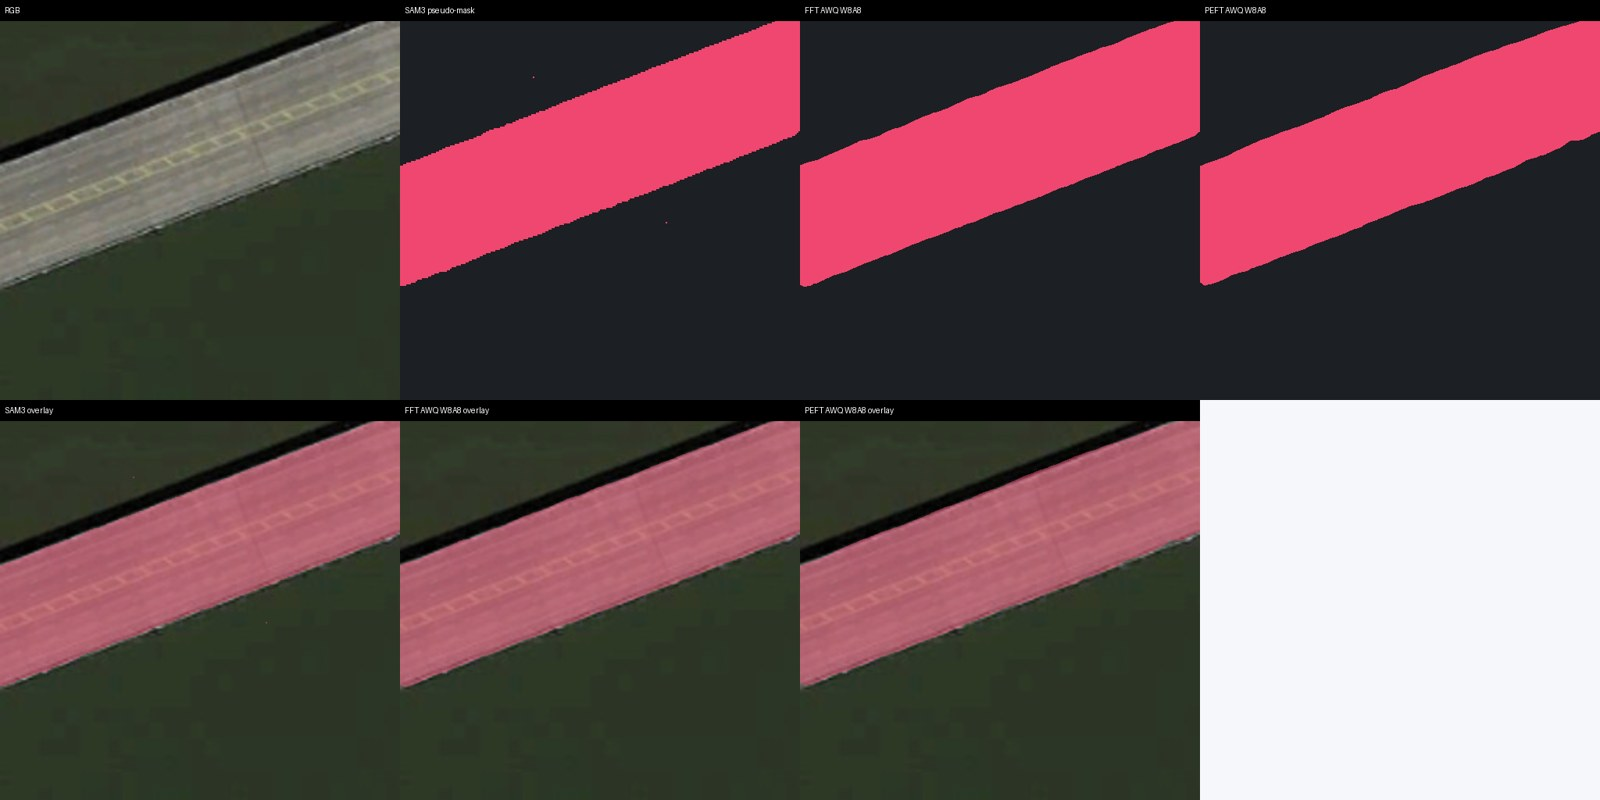

**AWQ W8A8 review panel — freeway**

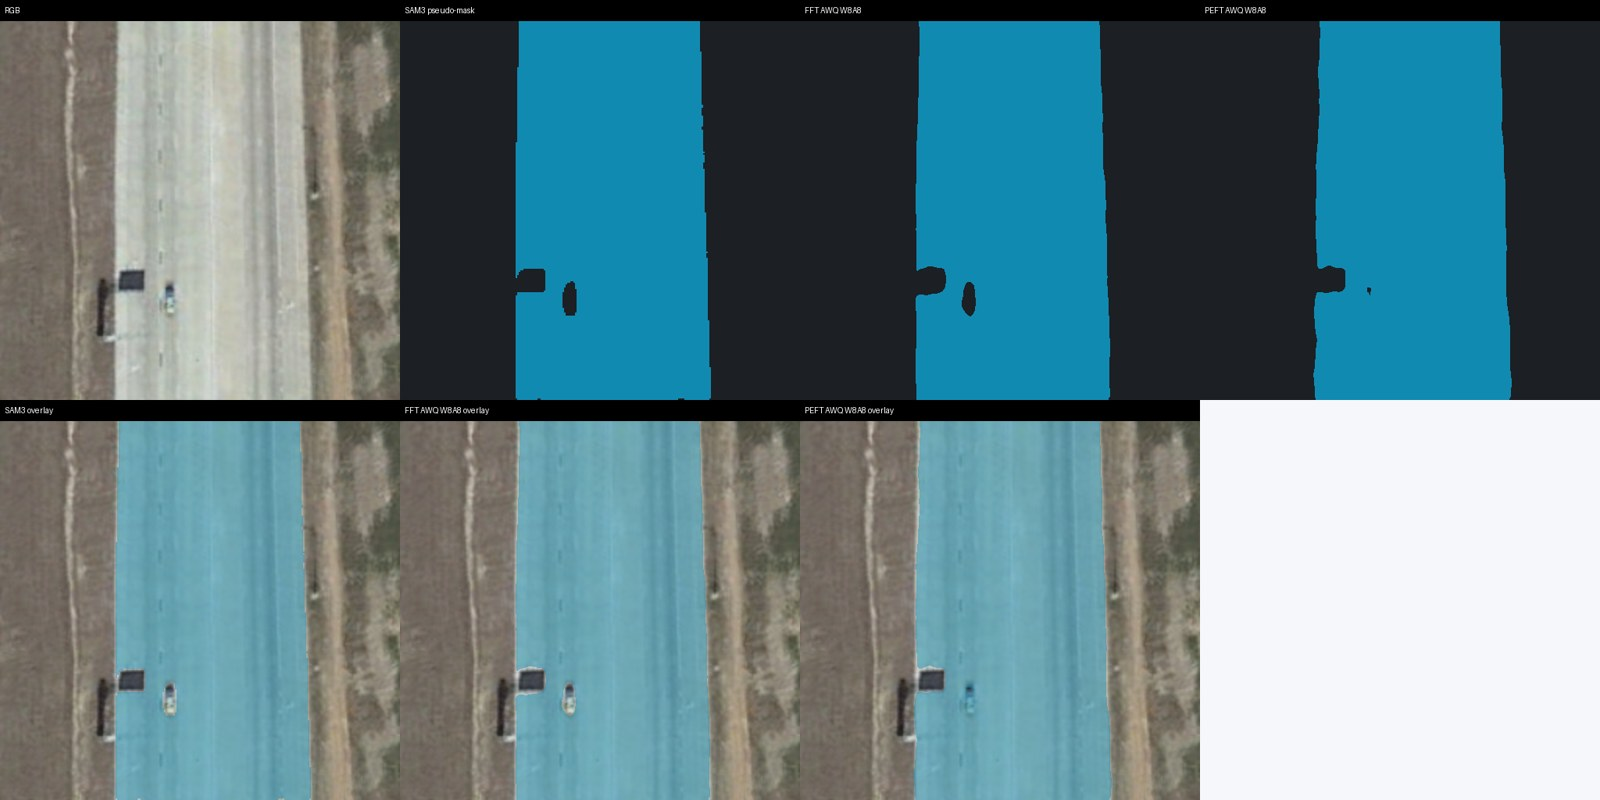

**AWQ W8A8 review panel — overpass**

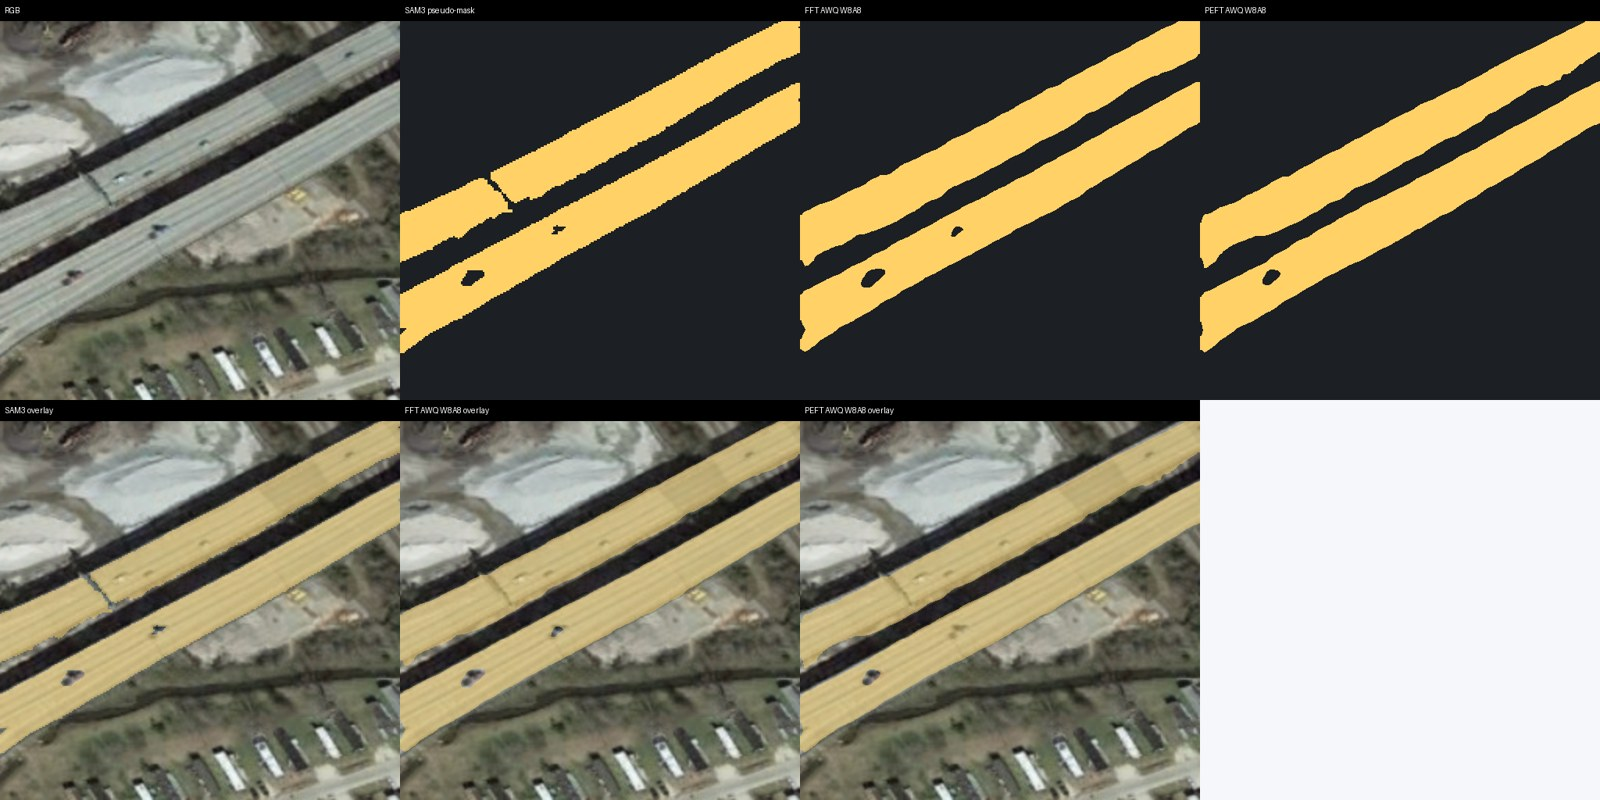

**AWQ W8A8 review panel — railway**

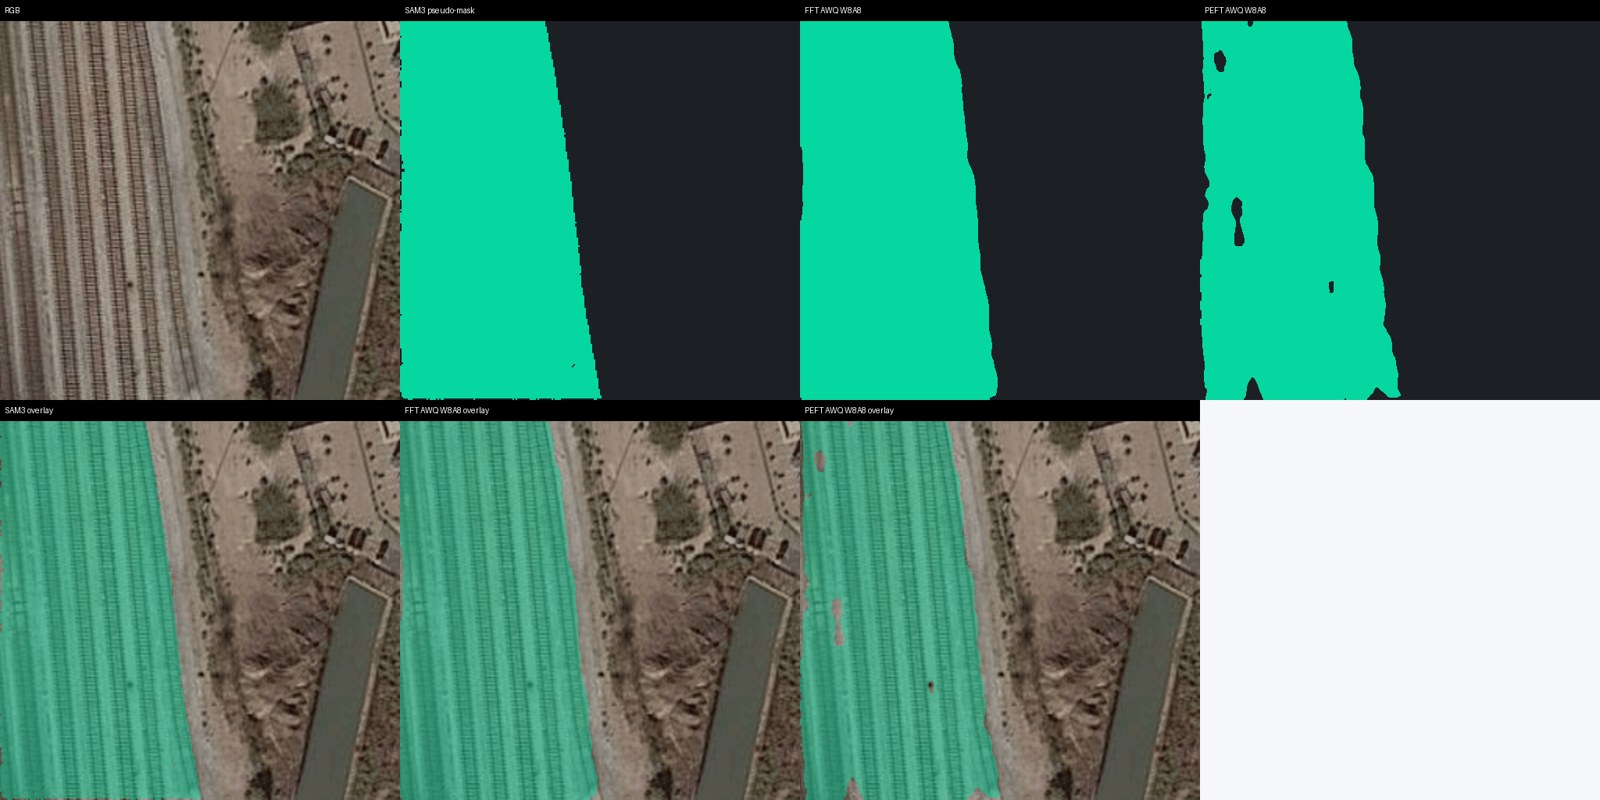

**Displayed AWQ W8A8 qualitative example metadata**

,scene_class_name,row_number,true_scene_name,peft_pred_scene_name,peft_pixel_accuracy,fft_pred_scene_name,fft_pixel_accuracy,joint_pixel_acc,comparison_panel_path
0,bridge,98,bridge,bridge,0.9933,bridge,0.9952,0.9933,reports/figure...
1,freeway,1396,freeway,freeway,0.9927,freeway,0.9955,0.9927,reports/figure...
2,overpass,2003,overpass,overpass,0.9816,overpass,0.9855,0.9816,reports/figure...
3,railway,2193,railway,railway,0.9787,railway,0.9909,0.9787,reports/figure...


In [16]:
if require_artifacts(['AWQ example metadata'], 'qualitative AWQ-style semantic evidence'):
    example_metadata = load_csv(ARTIFACTS['AWQ example metadata']).copy()
    example_metadata['joint_pixel_acc'] = example_metadata[['peft_pixel_accuracy', 'fft_pixel_accuracy']].min(axis=1)
    selected_examples = (
        example_metadata.sort_values(['scene_class_name', 'joint_pixel_acc'], ascending=[True, False])
        .groupby('scene_class_name', as_index=False)
        .head(1)
        .set_index('scene_class_name')
        .loc[CLASS_NAMES]
    )

    for scene, row in selected_examples.iterrows():
        panel_path = Path(row['comparison_panel_path'])
        if panel_path.is_absolute():
            panel_path = remap_remote_path(panel_path) if 'remap_remote_path' in globals() else panel_path
        else:
            panel_path = PROJECT_ROOT / panel_path
        display_image_artifact(panel_path, f'AWQ W8A8 review panel — {scene}', width=1200)

    display_table(
        selected_examples.reset_index()[[
            'scene_class_name', 'row_number', 'true_scene_name', 'peft_pred_scene_name',
            'peft_pixel_accuracy', 'fft_pred_scene_name', 'fft_pixel_accuracy', 'joint_pixel_acc',
            'comparison_panel_path',
        ]],
        'Displayed AWQ W8A8 qualitative example metadata',
    )
else:
    example_metadata = pd.DataFrame()


### AWQ-style FFT versus ONNX INT8 QDQ on difficult examples

To make the research question concrete, the FFT AWQ-style emulation is evaluated on the same two examples used to expose ONNX INT8 segmentation fragility: the lowest-margin `railway701` validation case and the Johor/CIQ interchange stress case.

This is not an ONNX deployment benchmark. It asks whether an activation-aware PyTorch emulation can retain semantic masks closer to FP32 than standard ONNX INT8 QDQ. In both examples, FFT AWQ-style W8A8 remains much closer to ONNX FP32 than the deployable INT8 QDQ mask, suggesting that activation-aware quantisation is a promising research direction for preserving dense segmentation quality.

**FFT AWQ-style W8A8 compared with ONNX INT8 QDQ on difficult cases**

,case_id,onnx_fp32_scene,onnx_fp32_confidence,onnx_int8_scene,onnx_int8_confidence,awq_scene,awq_confidence,awq_vs_onnx_int8_pixel_agreement,awq_vs_onnx_fp32_pixel_agreement
0,railway701,railway,0.9492,railway,0.5784,railway,0.9462,0.8510,0.9763
1,johor_ciq,overpass,0.8882,overpass,0.5964,overpass,0.8911,0.8595,0.9768


**railway701: FFT AWQ-style W8A8 versus ONNX INT8 QDQ**

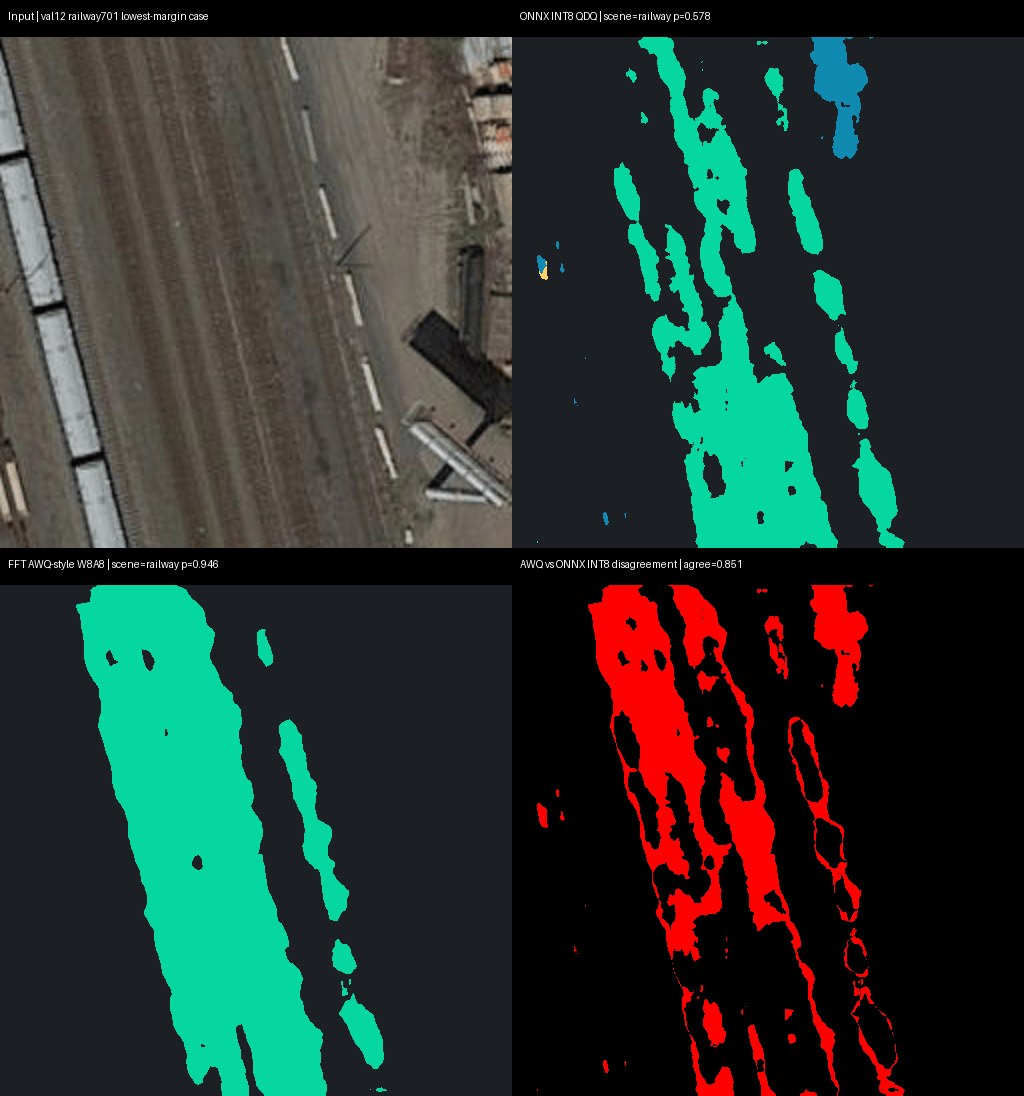

**Johor/CIQ: FFT AWQ-style W8A8 versus ONNX INT8 QDQ**

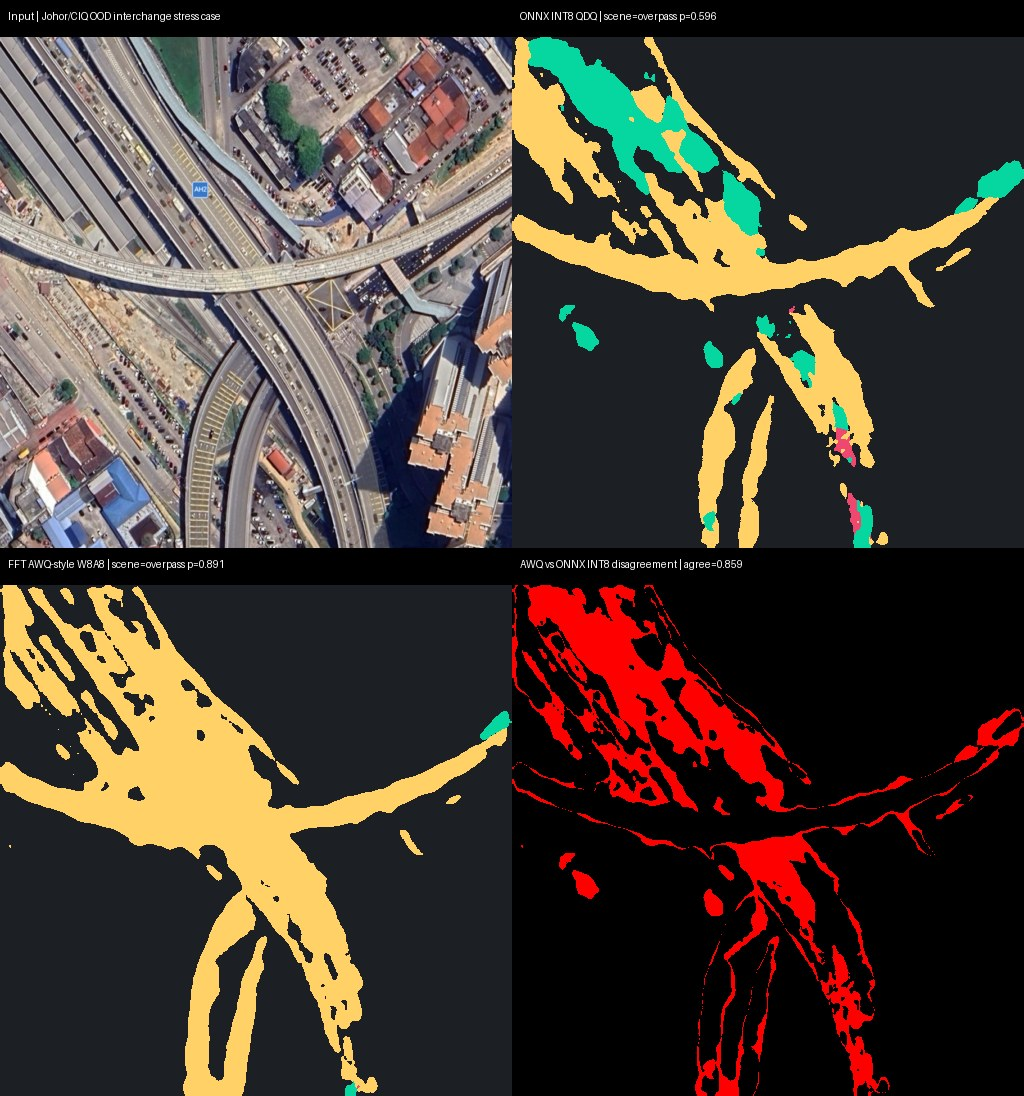

In [17]:
AWQ_ONNX_CASE_DIR = pipeline_output_path('awq_onnx_case_study_dir')
AWQ_ONNX_CASE_SUMMARY = AWQ_ONNX_CASE_DIR / 'fft_awq_vs_onnx_int8_case_summary.csv'

if AWQ_ONNX_CASE_SUMMARY.exists():
    awq_onnx_cases = load_csv(AWQ_ONNX_CASE_SUMMARY)
    display_table(
        awq_onnx_cases[[
            'case_id', 'onnx_fp32_scene', 'onnx_fp32_confidence',
            'onnx_int8_scene', 'onnx_int8_confidence',
            'awq_scene', 'awq_confidence',
            'awq_vs_onnx_int8_pixel_agreement', 'awq_vs_onnx_fp32_pixel_agreement',
        ]],
        'FFT AWQ-style W8A8 compared with ONNX INT8 QDQ on difficult cases',
    )
    for case_id, title in [
        ('railway701', 'railway701: FFT AWQ-style W8A8 versus ONNX INT8 QDQ'),
        ('johor_ciq', 'Johor/CIQ: FFT AWQ-style W8A8 versus ONNX INT8 QDQ'),
    ]:
        panel = AWQ_ONNX_CASE_DIR / f'{case_id}_fft_awq_vs_onnx_int8_panel.png'
        if panel.exists():
            display_image_artifact(panel, title, width=1000)
else:
    display(Markdown('AWQ-vs-ONNX case-study artifacts are unavailable; generate the `awq-onnx-case-study` pipeline stage to render this bonus comparison.'))


## 18. Size comparison and edge delivery

The PyTorch size rows describe model-state tensor size under FP32 and AWQ-style W8A8 emulation. The ONNX rows describe serialized deployment payloads. They are not identical file formats, but together they show the practical edge-delivery tradeoff: custom activation-aware experiments can be compact, while the native ONNX INT8 QDQ artifact is the deployable payload.


**FFT PyTorch model-state size by quantisation mode**

,checkpoint,mode,weight_bits,activation_bits,state_tensor_mib_emulated,state_tensor_mib_theoretical_packed,compression_vs_fp32_tensor,compression_vs_fp32_theoretical
0,fft,fp32,NaN,NaN,108.5395,108.5395,1.000x,1.000x
1,fft,awq_w8a8,8.0,8.0,27.6930,27.6930,3.919x,3.919x


**PyTorch AWQ-style state size and ONNX deployment payload size**

,artifact,format,raw_mib,gzip_mib,notes
0,PyTorch state: fp32,PyTorch state tensors,108.5395,NaN,1.000x
1,PyTorch state: awq_w8a8,PyTorch state tensors,27.6930,NaN,3.919x
2,onnx_fp32,Serialized ONNX payload,108.7003,100.9514,gzip ratio 0.929
3,onnx_int8_qdq_fullcalib_minmax,Serialized ONNX payload,27.9629,18.6963,gzip ratio 0.669


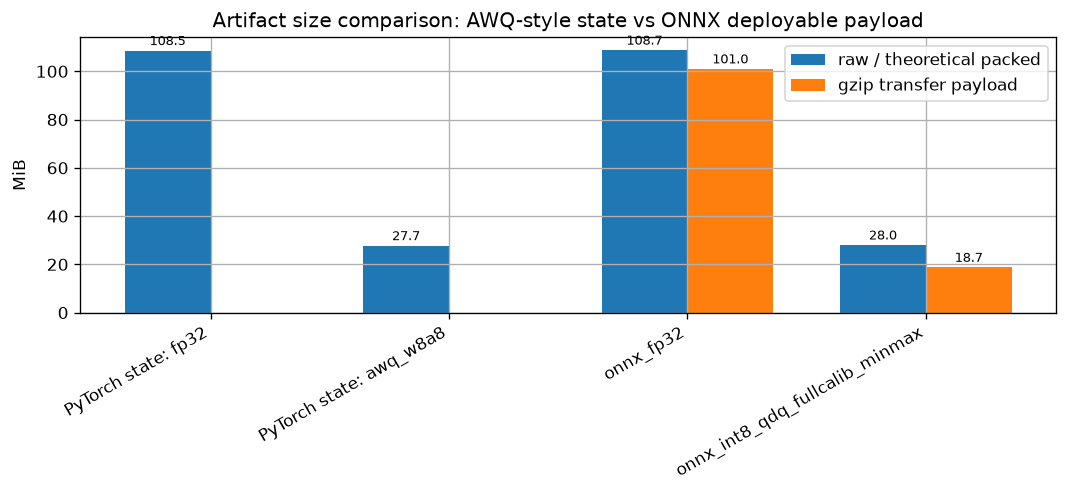

In [18]:
size_rows = []
if require_artifacts(['Model size summary'], 'model size summary'):
    size_summary = load_csv(ARTIFACTS['Model size summary'])
    size_fft = size_summary.loc[size_summary['checkpoint'].eq('fft')].copy()
    size_order = ['fp32', 'fp16', 'ptq_w8a8', 'awq_w8a8', 'ptq_w4a8', 'awq_w4a8']
    size_fft['mode'] = pd.Categorical(size_fft['mode'], categories=size_order, ordered=True)
    size_fft = size_fft.sort_values('mode')
    size_view = size_fft[[
        'checkpoint', 'mode', 'weight_bits', 'activation_bits',
        'state_tensor_mib_emulated', 'state_tensor_mib_theoretical_packed',
        'compression_vs_fp32_tensor', 'compression_vs_fp32_theoretical'
    ]]
    display_table(size_view, 'FFT PyTorch model-state size by quantisation mode')
    for _, row in size_fft.iterrows():
        size_rows.append({
            'artifact': f"PyTorch state: {row['mode']}",
            'format': 'PyTorch state tensors',
            'raw_mib': float(row['state_tensor_mib_theoretical_packed']),
            'gzip_mib': np.nan,
            'notes': row['compression_vs_fp32_theoretical'],
        })
else:
    size_summary = pd.DataFrame()

if 'onnx_delivery' in globals() and isinstance(onnx_delivery, pd.DataFrame) and not onnx_delivery.empty:
    for _, row in onnx_delivery.iterrows():
        size_rows.append({
            'artifact': row['artifact'],
            'format': 'Serialized ONNX payload',
            'raw_mib': float(row['raw_mib']),
            'gzip_mib': float(row['gzip_mib']),
            'notes': f"gzip ratio {row['gzip_ratio']:.3f}",
        })

if size_rows:
    edge_size_view = pd.DataFrame(size_rows)
    display_table(edge_size_view, 'PyTorch AWQ-style state size and ONNX deployment payload size')
    fig, ax = plt.subplots(figsize=(9, 4.2))
    x = np.arange(len(edge_size_view))
    ax.bar(x - 0.18, edge_size_view['raw_mib'], width=0.36, label='raw / theoretical packed')
    gzip_values = edge_size_view['gzip_mib'].fillna(0.0)
    ax.bar(x + 0.18, gzip_values, width=0.36, label='gzip transfer payload')
    ax.set_title('Artifact size comparison: AWQ-style state vs ONNX deployable payload')
    ax.set_ylabel('MiB')
    ax.set_xticks(x, edge_size_view['artifact'], rotation=30, ha='right')
    ax.legend()
    for idx, value in enumerate(edge_size_view['raw_mib']):
        ax.text(idx - 0.18, value + 1.0, f'{value:.1f}', ha='center', va='bottom', fontsize=8)
    for idx, value in enumerate(gzip_values):
        if value > 0:
            ax.text(idx + 0.18, value + 1.0, f'{value:.1f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('No size artifacts available for this run.'))


## 19. Final selected result and quantisation interpretation

The selected architecture remains the staged FFT `Semantic-Guided CG-AF CNN`. The quantisation story has two distinct roles:

1. **AWQ-style W8A8 PyTorch emulation** is a custom activation-aware research/proxy implementation. It is used to test whether the model remains robust under state-of-the-art activation-aware quantisation ideas and to study segmentation/classification stability. It should not be described as a native ONNX/NPU deployment artifact.
2. **Full-calibrated ONNX INT8 QDQ** is the deployment-realistic artifact. It uses standard ONNX Runtime static post-training quantisation with calibration, producing a portable QDQ graph that is more likely to map onto mobile/edge NPU compilation paths.

So the final result is not “AWQ deployment”. The final result is: **Semantic-Guided CG-AF CNN selected by the AWQ-style robustness study, then deployed through calibrated ONNX INT8 QDQ for practical edge delivery.**


In [19]:
onnx_delivery_path = pipeline_output_path('onnx_delivery_size_summary')
onnx_val12_summary_path = pipeline_output_path('unseen_output_dir') / 'summary.csv'
final_rows = [
    '| Item | Value |',
    '|---|---:|',
    '| Selected architecture | Semantic-Guided CG-AF CNN |',
    '| Selected checkpoint path | BF16 staged FFT checkpoint; ONNX INT8 produced by static PTQ/QDQ calibration |',
]

if 'awq_summary' in globals() and isinstance(awq_summary, pd.DataFrame) and not awq_summary.empty and 'size_summary' in globals() and isinstance(size_summary, pd.DataFrame) and not size_summary.empty:
    final_awq = awq_summary.loc[awq_summary['model'].eq('fft_awq_w8a8')].iloc[0]
    final_size = size_summary.loc[
        size_summary['checkpoint'].eq('fft') & size_summary['mode'].eq('awq_w8a8')
    ].iloc[0]
    final_rows.extend([
        '| Research quantisation stress test | Custom AWQ-style W8A8 PyTorch emulation |',
        '| AWQ-style purpose | Activation-aware robustness/proxy evaluation, not native deployment |',
        f"| AWQ-style macro-F1 | {final_awq['macro_f1']:.4f} |",
        f"| AWQ-style pseudo-mask mIoU | {final_awq['seg_mean_iou']:.4f} |",
        f"| AWQ-style theoretical packed state size | {final_size['state_tensor_mib_theoretical_packed']:.2f} MiB |",
        f"| AWQ-style compression versus FP32 | {final_size['compression_vs_fp32_theoretical']} |",
    ])
else:
    final_rows.extend([
        '| Research quantisation stress test | Custom AWQ-style W8A8 PyTorch emulation; generated artifact not present in this local run |',
        '| AWQ-style purpose | Activation-aware robustness/proxy evaluation, not native deployment |',
    ])

if onnx_delivery_path.exists() and onnx_val12_summary_path.exists():
    onnx_delivery_now = load_csv(onnx_delivery_path)
    onnx_val12_now = load_csv(onnx_val12_summary_path)
    int8_delivery = onnx_delivery_now.loc[onnx_delivery_now['artifact'].eq('onnx_int8_qdq_fullcalib_minmax')].iloc[0]
    fp32_delivery = onnx_delivery_now.loc[onnx_delivery_now['artifact'].eq('onnx_fp32')].iloc[0]
    onnx_int8_val12 = onnx_val12_now.loc[onnx_val12_now['variant'].eq('onnx_int8_qdq')].iloc[0]
    final_rows.extend([
        '| Native deployable artifact | Full-calibrated ONNX INT8 QDQ |',
        f"| ONNX INT8 val12 accuracy | {onnx_int8_val12['accuracy']:.4f} |",
        f"| ONNX INT8 raw artifact size | {int8_delivery['raw_mib']:.2f} MiB |",
        f"| ONNX INT8 compressed delivery size | {int8_delivery['gzip_mib']:.2f} MiB |",
        f"| Compressed INT8 vs compressed FP32 | {fp32_delivery['gzip_mib'] / int8_delivery['gzip_mib']:.2f}x smaller |",
    ])
else:
    final_rows.append('| Native deployable artifact | Full-calibrated ONNX INT8 QDQ; generate/copy ONNX artifacts to render metrics |')

summary_md = "### Final model decision\n\n" + "\n".join(final_rows) + "\n\n" + (
    "**Decision:** choose staged FFT because it is stable under activation-aware quantisation pressure and preserves stronger semantic segmentation quality. "
    "For realistic deployment, use the full-calibrated ONNX INT8 QDQ artifact rather than treating the custom AWQ-style PyTorch emulation as a native NPU artifact."
)
display(Markdown(summary_md))


### Final model decision

| Item | Value |
|---|---:|
| Selected architecture | Semantic-Guided CG-AF CNN |
| Selected checkpoint path | BF16 staged FFT checkpoint; ONNX INT8 produced by static PTQ/QDQ calibration |
| Research quantisation stress test | Custom AWQ-style W8A8 PyTorch emulation |
| AWQ-style purpose | Activation-aware robustness/proxy evaluation, not native deployment |
| AWQ-style macro-F1 | 1.0000 |
| AWQ-style pseudo-mask mIoU | 0.8106 |
| AWQ-style theoretical packed state size | 27.69 MiB |
| AWQ-style compression versus FP32 | 3.919x |
| Native deployable artifact | Full-calibrated ONNX INT8 QDQ |
| ONNX INT8 val12 accuracy | 1.0000 |
| ONNX INT8 raw artifact size | 27.96 MiB |
| ONNX INT8 compressed delivery size | 18.70 MiB |
| Compressed INT8 vs compressed FP32 | 5.40x smaller |

**Decision:** choose staged FFT because it is stable under activation-aware quantisation pressure and preserves stronger semantic segmentation quality. For realistic deployment, use the full-calibrated ONNX INT8 QDQ artifact rather than treating the custom AWQ-style PyTorch emulation as a native NPU artifact.

## 20. Limitations

Important limitations to keep explicit:

- SAM3 masks are pseudo-labels, not human-verified ground truth.
- The classification result validates the segmentation-guided semantic distillation pipeline, not a pure image-only classifier.
- The AWQ-style W8A8 path is a custom PyTorch emulation/proxy for activation-aware quantisation robustness, not a native ONNX/NPU deployment format.
- The native deployment path is ONNX Runtime static INT8 QDQ/PTQ with calibration.
- ONNX export alone does not guarantee full NPU execution; target execution-provider/compiler validation is still required.
- Although full-calibrated ONNX INT8 QDQ preserved 400/400 scene accuracy on `val 12`, a separate Johor qualitative image showed degraded INT8 segmentation masks relative to ONNX FP32 while scene classification remained correct. This suggests that the segmentation branch is more quantisation-sensitive than the scene head.
- Backend-specific hardware latency and energy profiling remain future work.


## 21. Generated artifacts

The final report-ready artifacts used by this notebook are listed below.

In [20]:
final_artifact_rows = [
    {'type': 'pipeline manifest', 'location': 'local', 'path': str(PIPELINE_MANIFEST_PATH.relative_to(PROJECT_ROOT)) if PIPELINE_MANIFEST_PATH else str(TABLE_ARTIFACTS['Pipeline manifest'].relative_to(PROJECT_ROOT))},
    {'type': 'quant summary', 'location': 'local/generated', 'path': str(pipeline_output_path('quant_summary').relative_to(PROJECT_ROOT)) if pipeline_output_path('quant_summary').is_relative_to(PROJECT_ROOT) else str(pipeline_output_path('quant_summary'))},
    {'type': 'checkpoint export manifest', 'location': 'local/generated', 'path': str(pipeline_output_path('checkpoint_export_manifest'))},
    {'type': 'AWQ mask export manifest', 'location': 'local/generated', 'path': str(mask_export_manifest_path.relative_to(PROJECT_ROOT)) if mask_export_manifest_path.is_relative_to(PROJECT_ROOT) else str(mask_export_manifest_path)},
    {'type': 'AWQ mask figure dir', 'location': 'local/generated', 'path': str(mask_figure_dir.relative_to(PROJECT_ROOT)) if mask_figure_dir.is_relative_to(PROJECT_ROOT) else str(mask_figure_dir)},
    {'type': 'ONNX val12 summary', 'location': 'local', 'path': str(pipeline_output_path('unseen_output_dir') / 'summary.csv')},
    {'type': 'ONNX review figure dir', 'location': 'local', 'path': str(pipeline_output_path('unseen_review_dir'))},
]
final_artifacts = pd.DataFrame(final_artifact_rows)
final_artifacts['available_for_notebook'] = final_artifacts['path'].map(lambda value: Path(value).exists() if Path(value).is_absolute() else (PROJECT_ROOT / value).exists())
display_table(final_artifacts[['type', 'location', 'available_for_notebook', 'path']], 'Notebook artifact index')


**Notebook artifact index**

,type,location,available_for_notebook,path
0,pipeline manifest,local,True,reports/tables/semantic_guided_cgaf_pipeline_s...
1,quant summary,local/generated,True,reports/tables/semantic_guided_cgaf_pipeline_s...
2,checkpoint export manifest,local/generated,True,CSC3109_P...
3,AWQ mask export manifest,local/generated,True,reports/tables/semantic_guided_cgaf_mask_expor...
4,AWQ mask figure dir,local/generated,True,reports/figures/semantic_guided_cgaf_mask_expo...
5,ONNX val12 summary,local,True,reports/tables/semantic_guided_cgaf_unseen_val...
6,ONNX review figure dir,local,True,reports/figures/semantic_guided_cgaf_unseen_va...
